In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [3]:
# df = pd.read_csv("data/par-to-par-subset.csv")
# df = pd.read_excel("data/par-to-par-2.xlsx")
df = pd.read_csv("../data/par-to-par-og.csv")

for col in ["DATE_FROM", "DATE_TO"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df.head()

,CELEX_FROM,TITLE_FROM,NUMBER_FROM,DATE_FROM,TEXT_FROM,CELEX_TO,TITLE_TO,NUMBER_TO,TEXT_TO,DATE_TO
0,61985CJ0341,Erik van der Stijl and Geoffrey Cullington v C...,18,1989-02-28,18 Those arguments need not be addressed . As ...,61976CJ0030,Berthold Küster v European Parliament.,8,8 IT CANNOT BE CONTESTED THAT THOSE TO WHOM A ...,1976-11-25
1,61985CJ0341,Erik van der Stijl and Geoffrey Cullington v C...,51,1989-02-28,51 The Court held in its judgment of 30 Octobe...,61973CJ0188,Daniele Grassi v Council of the European Commu...,38,"38 IN FACT, THOUGH THE APPOINTING AUTHORITY HA...",1974-10-30
2,61986CJ0062,AKZO Chemie BV v Commission of the European Co...,16,1991-07-03,"16 In that respect it should be observed that,...",61982CJ0043,Vereniging ter Bevordering van het Vlaamse Boe...,25,25 IN THAT CONNECTION IT MUST BE OBSERVED THAT...,1984-01-17
3,61986CJ0062,AKZO Chemie BV v Commission of the European Co...,51,1991-07-03,51 In its judgment in Case 31/80 L' Oréal v De...,61980CJ0031,"NV L'Oréal and SA L'Oréal v PVBA ""De Nieuwe AM...",25,25 AS THE COURT EMPHASIZED IN ITS JUDGMENT OF ...,1980-12-11
4,61986CJ0062,AKZO Chemie BV v Commission of the European Co...,60,1991-07-03,60 With regard to market shares the Court has ...,61976CJ0085,Hoffmann-La Roche & Co. AG v Commission of the...,41,41FURTHERMORE ALTHOUGH THE IMPORTANCE OF THE M...,1979-02-13


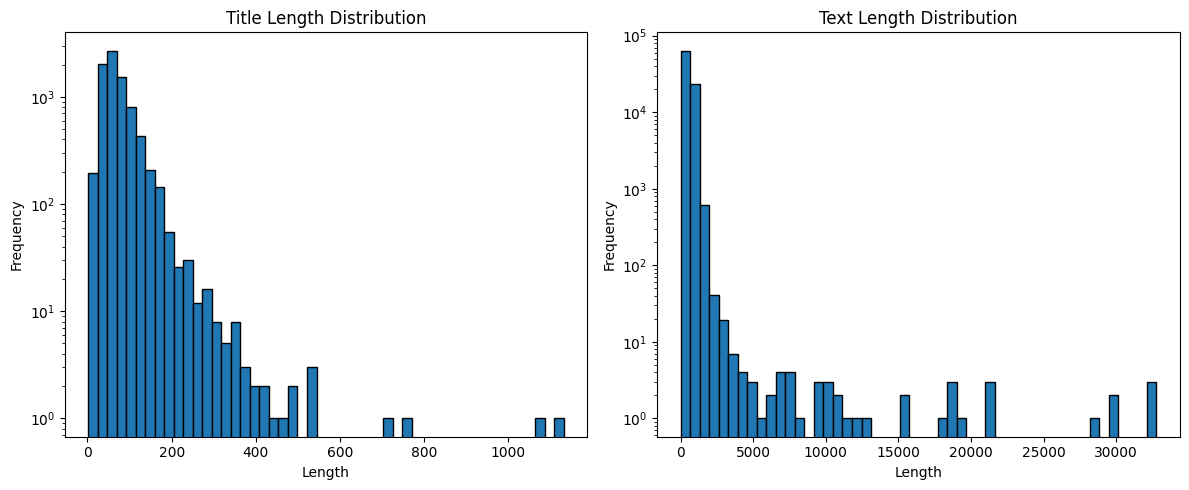

In [4]:
# Get unique nodes for titles
titles = pd.concat([df['TITLE_FROM'], df['TITLE_TO']]).dropna().unique()
title_lengths = pd.Series(titles).str.len()

# Get unique nodes for texts
texts = pd.concat([df['TEXT_FROM'], df['TEXT_TO']]).dropna().unique()
text_lengths = pd.Series(texts).str.len()

# Plot distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(title_lengths, bins=50, edgecolor='black')
plt.yscale("log")
plt.title('Title Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(text_lengths, bins=50, edgecolor='black')
plt.yscale("log")
plt.title('Text Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [5]:
# Combine and deduplicate
combined = pd.concat([df["TEXT_FROM"], df["TEXT_TO"]]).dropna().drop_duplicates()

# Count how many are longer than 5000 characters
count_over_5000 = (combined.str.len() > 2000).sum()

count_over_5000


np.int64(108)

In [6]:
# Create a table of statistics for title and text lengths
stats_data = {
    'Field': ['Title', 'Text'],
    'Mean': [
        title_lengths.mean(),
        text_lengths.mean()
    ],
    'Median': [
        title_lengths.median(),
        text_lengths.median()
    ],
    'Std Dev': [
        title_lengths.std(),
        text_lengths.std()
    ],
    'Min': [
        title_lengths.min(),
        text_lengths.min()
    ],
    'Max': [
        title_lengths.max(),
        text_lengths.max()
    ]
}

stats_df = pd.DataFrame(stats_data)
display(stats_df.round(2))

,Field,Mean,Median,Std Dev,Min,Max
0,Title,73.05,62.0,46.81,2,1132
1,Text,560.65,517.0,425.56,8,32767


In [7]:
# Compute percentiles for text lengths
percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
text_percentiles = text_lengths.quantile(percentiles)

# Display nicely formatted table
percentile_df = pd.DataFrame({
    'Percentile': [f'{int(p*100)}%' for p in percentiles],
    'Text Length': text_percentiles.round(2).values
})

display(percentile_df)


,Percentile,Text Length
0,1%,152.0
1,5%,236.0
2,10%,287.0
3,25%,383.0
4,50%,517.0
5,75%,686.0
6,90%,867.0
7,95%,988.0
8,99%,1284.0


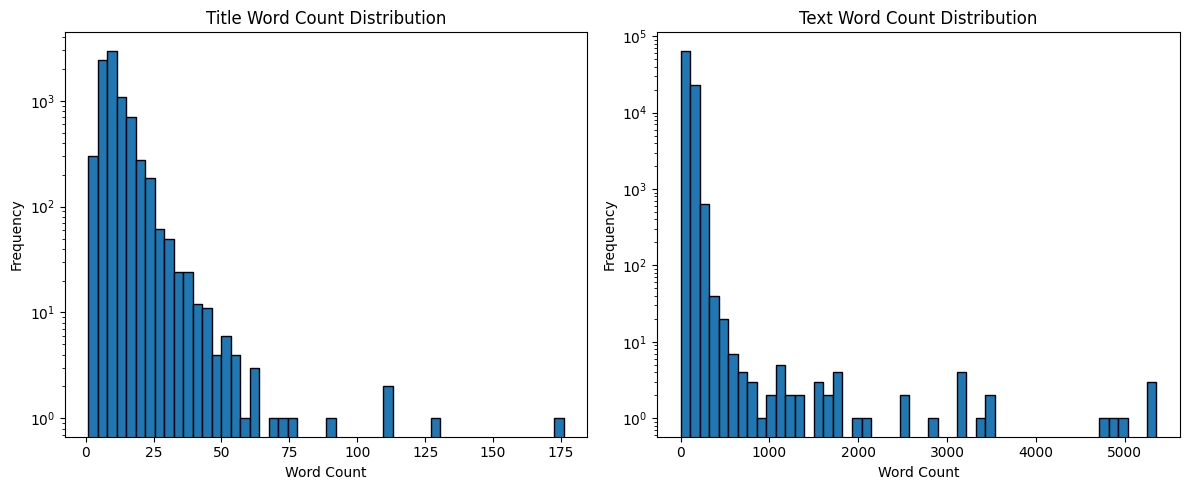

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Get unique nodes for titles
titles = pd.concat([df['TITLE_FROM'], df['TITLE_TO']]).dropna().unique()
title_word_counts = pd.Series(titles).apply(lambda x: len(str(x).split()))

# Get unique nodes for texts
texts = pd.concat([df['TEXT_FROM'], df['TEXT_TO']]).dropna().unique()
text_word_counts = pd.Series(texts).apply(lambda x: len(str(x).split()))

# Plot distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(title_word_counts, bins=50, edgecolor='black')
plt.yscale("log")
plt.title('Title Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(text_word_counts, bins=50, edgecolor='black')
plt.yscale("log")
plt.title('Text Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [9]:
# Create a table of statistics for title and text lengths
stats_data = {
    'Field': ['Title', 'Text'],
    'Mean': [
        title_word_counts.mean(),
        text_word_counts.mean()
    ],
    'Median': [
        title_word_counts.median(),
        text_word_counts.median()
    ],
    'Std Dev': [
        title_word_counts.std(),
        text_word_counts.std()
    ],
    'Min': [
        title_word_counts.min(),
        text_word_counts.min()
    ],
    'Max': [
        title_word_counts.max(),
        text_word_counts.max()
    ]
}

stats_df = pd.DataFrame(stats_data)
display(stats_df.round(2))

,Field,Mean,Median,Std Dev,Min,Max
0,Title,10.51,9.0,6.66,1,176
1,Text,91.55,84.0,69.85,2,5357


In [10]:
# Compute percentiles for text lengths
percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
text_percentiles = text_word_counts.quantile(percentiles)

# Display nicely formatted table
percentile_df = pd.DataFrame({
    'Percentile': [f'{int(p*100)}%' for p in percentiles],
    'Text Length': text_percentiles.round(2).values
})

display(percentile_df)


,Percentile,Text Length
0,1%,25.0
1,5%,39.0
2,10%,47.0
3,25%,62.0
4,50%,84.0
5,75%,112.0
6,90%,142.0
7,95%,162.0
8,99%,211.0


/Users/christianjensen/Documents/Master-Thesis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Token indices sequence length is longer than the specified maximum sequence length for this model (8237 > 8192). Running this sequence through the model will result in indexing errors


Title Token Statistics:
  Mean: 21.4
  Median: 18.0
  25th percentile: 14.0
  95th percentile: 42.0
  99th percentile: 69.0
  Max: 386

Text Token Statistics:
  Mean: 137.1
  Median: 126.0
  25th percentile: 93.0
  95th percentile: 245.0
  99th percentile: 335.0
  Max: 8237


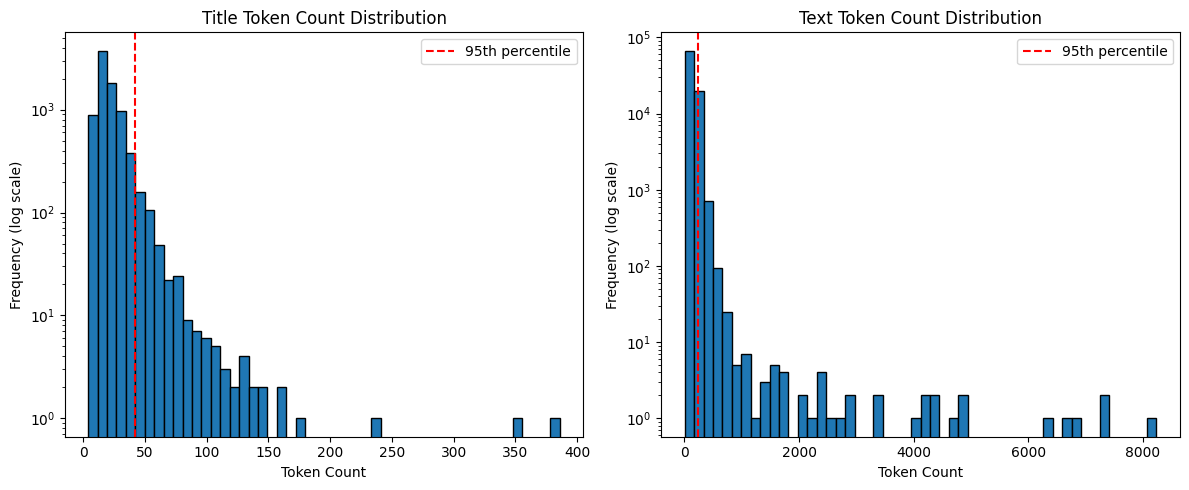

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# Load BGE-M3 tokenizer
tokenizer = AutoTokenizer.from_pretrained('BAAI/bge-m3')

# Get unique nodes for titles
titles = pd.concat([df['TITLE_FROM'], df['TITLE_TO']]).dropna().unique()
title_token_counts = pd.Series(titles).apply(lambda x: len(tokenizer.encode(str(x))))

# Get unique nodes for texts
texts = pd.concat([df['TEXT_FROM'], df['TEXT_TO']]).dropna().unique()
text_token_counts = pd.Series(texts).apply(lambda x: len(tokenizer.encode(str(x))))

# Print statistics
print("Title Token Statistics:")
print(f"  Mean: {title_token_counts.mean():.1f}")
print(f"  Median: {title_token_counts.median():.1f}")
print(f"  25th percentile: {title_token_counts.quantile(0.25):.1f}")
print(f"  95th percentile: {title_token_counts.quantile(0.95):.1f}")
print(f"  99th percentile: {title_token_counts.quantile(0.99):.1f}")
print(f"  Max: {title_token_counts.max()}")

print("\nText Token Statistics:")
print(f"  Mean: {text_token_counts.mean():.1f}")
print(f"  Median: {text_token_counts.median():.1f}")
print(f"  25th percentile: {text_token_counts.quantile(0.25):.1f}")
print(f"  95th percentile: {text_token_counts.quantile(0.95):.1f}")
print(f"  99th percentile: {text_token_counts.quantile(0.99):.1f}")
print(f"  Max: {text_token_counts.max()}")

# Plot distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(title_token_counts, bins=50, edgecolor='black')
plt.yscale("log")
plt.title('Title Token Count Distribution')
plt.xlabel('Token Count')
plt.ylabel('Frequency (log scale)')
plt.axvline(title_token_counts.quantile(0.95), color='r', linestyle='--', label='95th percentile')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(text_token_counts, bins=50, edgecolor='black')
plt.yscale("log")
plt.title('Text Token Count Distribution')
plt.xlabel('Token Count')
plt.ylabel('Frequency (log scale)')
plt.axvline(text_token_counts.quantile(0.95), color='r', linestyle='--', label='95th percentile')
plt.legend()

plt.tight_layout()
plt.show()

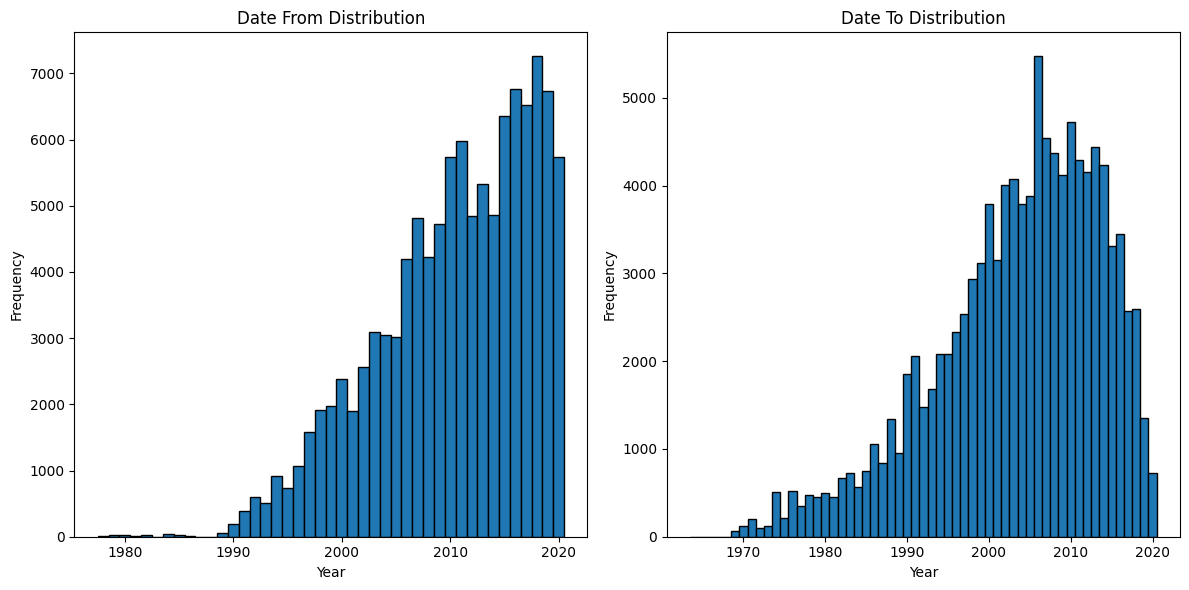

In [12]:
# Plot DATE_FROM and DATE_TO distribution with each bar representing a year
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(pd.to_datetime(df['DATE_FROM']).dt.year, bins=range(df['DATE_FROM'].min().year, df['DATE_FROM'].max().year + 1), edgecolor='black', align='left')
plt.title('Date From Distribution')
plt.xlabel('Year')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(pd.to_datetime(df['DATE_TO']).dt.year, bins=range(df['DATE_TO'].min().year, df['DATE_TO'].max().year + 1), edgecolor='black', align='left')
plt.title('Date To Distribution')
plt.xlabel('Year')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [13]:
# Imports
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Build paragraph-level node ids
df["PAR_FROM"] = df["CELEX_FROM"].astype(str) + "§" + df["NUMBER_FROM"].astype(str)
df["PAR_TO"]   = df["CELEX_TO"].astype(str)   + "§" + df["NUMBER_TO"].astype(str)

# ---- BASIC STATS ----
n_edges = len(df)
n_unique_paragraph_nodes = pd.Index(pd.concat([df["PAR_FROM"], df["PAR_TO"]])).nunique()
n_unique_case_nodes = pd.Index(pd.concat([df["CELEX_FROM"], df["CELEX_TO"]])).nunique()
n_unique_case_pairs = df[["CELEX_FROM","CELEX_TO"]].drop_duplicates().shape[0]
n_unique_paragraph_pairs = df[["PAR_FROM","PAR_TO"]].drop_duplicates().shape[0]
n_self_case_edges = (df["CELEX_FROM"] == df["CELEX_TO"]).sum()

# Duplicate edges count (exact row duplicates on PAR_FROM->PAR_TO)
duplicate_edges = n_edges - n_unique_paragraph_pairs

# ---- TEMPORAL STATS ----
valid_temporal = (df["DATE_FROM"] >= df["DATE_TO"]).sum()
invalid_temporal = (df["DATE_FROM"] < df["DATE_TO"]).sum()
equal_dates = (df["DATE_FROM"] == df["DATE_TO"]).sum()

basic_stats = pd.DataFrame([{
    "edges": n_edges,
    "unique_paragraph_nodes": n_unique_paragraph_nodes,
    "unique_case_nodes": n_unique_case_nodes,
    "unique_paragraph_pairs": n_unique_paragraph_pairs,
    "unique_case_pairs": n_unique_case_pairs,
    "duplicate_edges_paragraph_level": duplicate_edges,
    "self_case_edges": n_self_case_edges,
    "temporal_ok (DATE_FROM>=DATE_TO)": valid_temporal,
    "temporal_violations (DATE_FROM<DATE_TO)": invalid_temporal,
    "equal_dates": equal_dates
}])
basic_stats

,edges,unique_paragraph_nodes,unique_case_nodes,unique_paragraph_pairs,unique_case_pairs,duplicate_edges_paragraph_level,self_case_edges,temporal_ok (DATE_FROM>=DATE_TO),temporal_violations (DATE_FROM<DATE_TO),equal_dates
0,110179,88229,10401,110179,55947,0,0,110179,0,396


In [14]:
# Build a directed graph
G = nx.DiGraph()
G.add_edges_from(df[["PAR_FROM", "PAR_TO"]].itertuples(index=False, name=None))

n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)
avg_degree = sum(dict(G.degree()).values()) / n_nodes


in_degrees = [d for n, d in G.in_degree()]
out_degrees = [d for n, d in G.out_degree()]
max_in = max(in_degrees)
max_out = max(out_degrees)
n_weak_components = nx.number_weakly_connected_components(G)
n_strong_components = nx.number_strongly_connected_components(G)
largest_weak = max(len(c) for c in nx.weakly_connected_components(G))
largest_strong = max(len(c) for c in nx.strongly_connected_components(G))
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, k=500, seed=42)  # sample for large graphs
pagerank = nx.pagerank(G, alpha=0.85)
reciprocity = nx.reciprocity(G)
assortativity = nx.degree_assortativity_coefficient(G)
graph_stats = pd.DataFrame([{
    "nodes": n_nodes,
    "edges": n_edges,
    "density": density,
    "avg_degree": avg_degree,
    "max_in_degree": max_in,
    "max_out_degree": max_out,
    "weak_components": n_weak_components,
    "strong_components": n_strong_components,
    "largest_weak_size": largest_weak,
    "largest_strong_size": largest_strong,
    "reciprocity": reciprocity,
    "assortativity": assortativity
}])
graph_stats

,nodes,edges,density,avg_degree,max_in_degree,max_out_degree,weak_components,strong_components,largest_weak_size,largest_strong_size,reciprocity,assortativity
0,88229,110179,0.000014,2.497569,102,94,10278,88215,47558,3,0.00029,-0.033047


In [15]:
graph_stats

,nodes,edges,density,avg_degree,max_in_degree,max_out_degree,weak_components,strong_components,largest_weak_size,largest_strong_size,reciprocity,assortativity
0,88229,110179,0.000014,2.497569,102,94,10278,88215,47558,3,0.00029,-0.033047


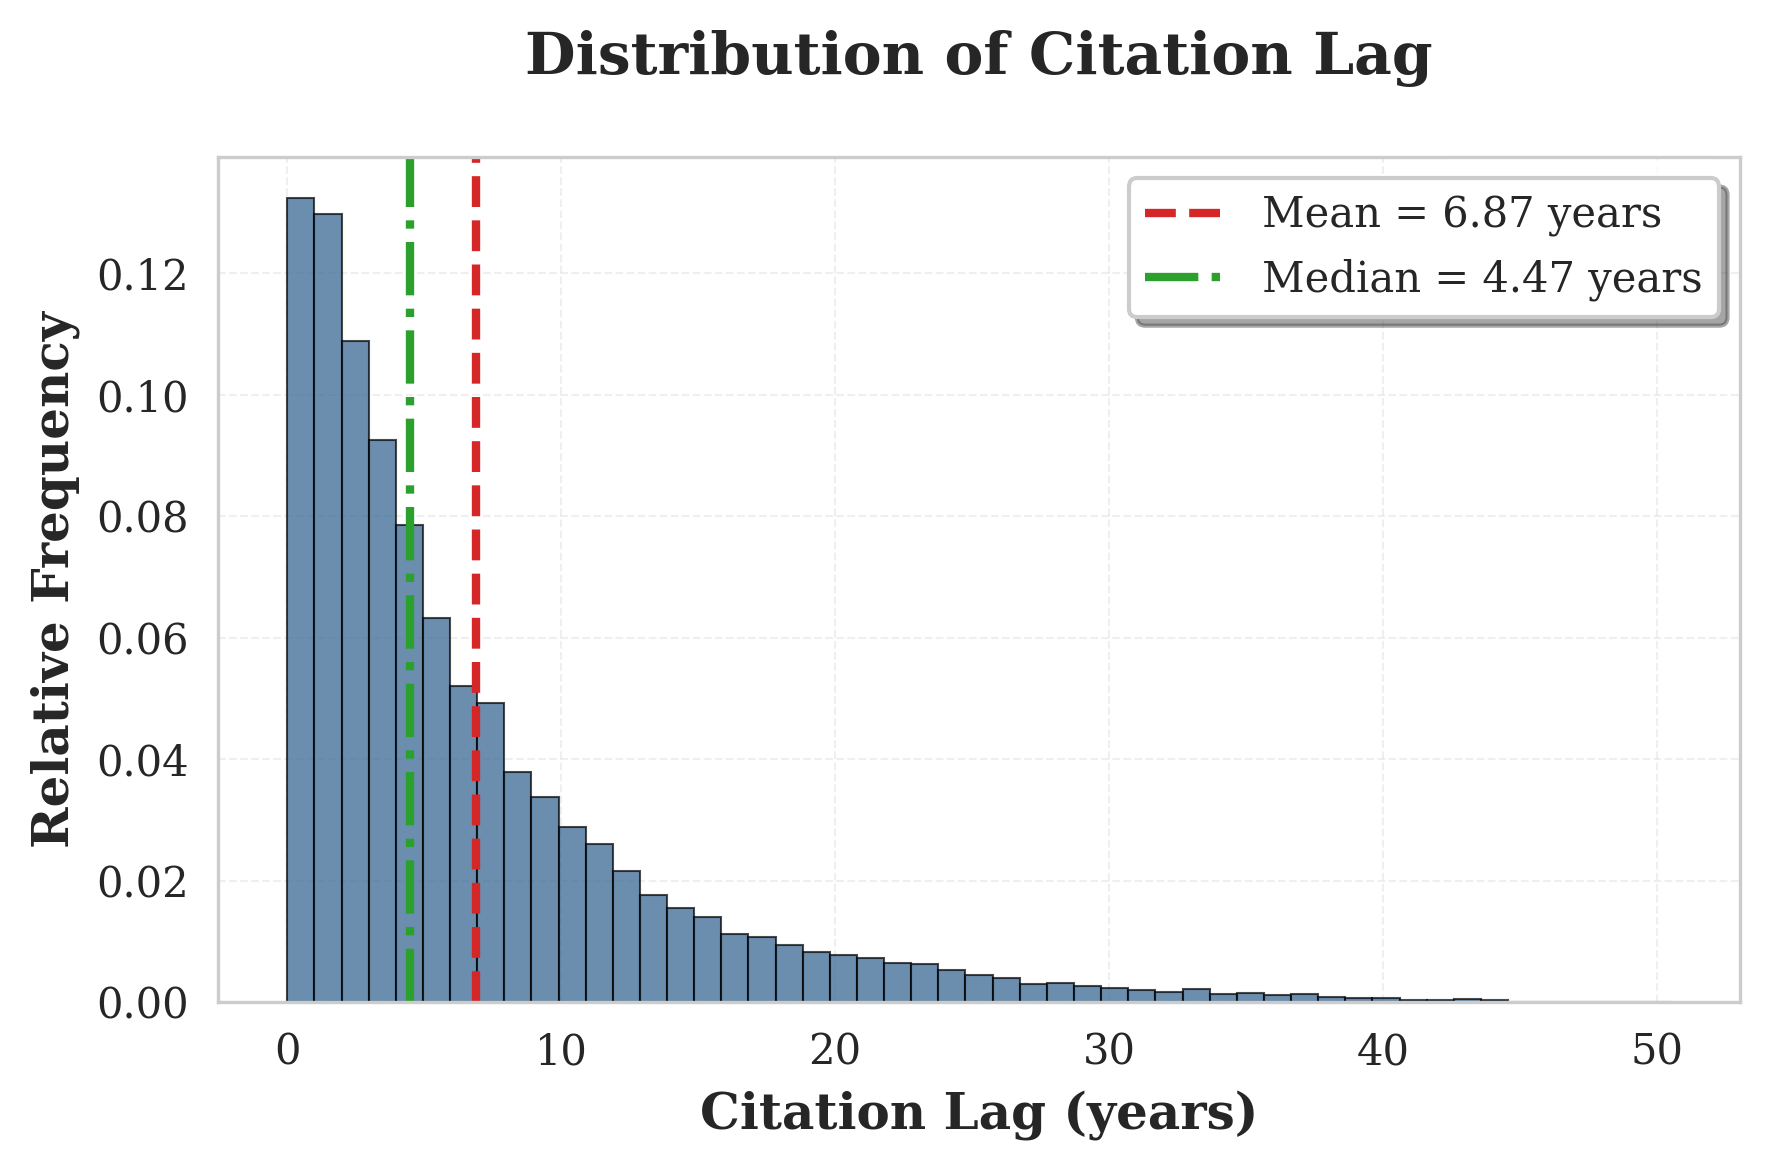


CITATION LAG ANALYSIS: SUMMARY STATISTICS
Sample size (N):          110,179
Mean:                     6.87 years
Standard deviation:       7.15 years
Median:                   4.47 years
10th percentile:          0.77 years
25th percentile (Q1):     1.90 years
75th percentile (Q3):     9.25 years
90th percentile:          16.46 years
Maximum:                  50.50 years



In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set academic style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10

# Citation lag in years (only when both dates present)
mask_dates = df["DATE_FROM"].notna() & df["DATE_TO"].notna()
lags_years = (df.loc[mask_dates, "DATE_FROM"] - df.loc[mask_dates, "DATE_TO"]).dt.days / 365.25
lags_years = lags_years[lags_years >= 0]  # keep only non-negative lags

# Summary statistics
lag_summary = {
    "count": int(lags_years.shape[0]),
    "mean_years": float(lags_years.mean()) if lags_years.shape[0] else np.nan,
    "median_years": float(lags_years.median()) if lags_years.shape[0] else np.nan,
    "std_years": float(lags_years.std()) if lags_years.shape[0] else np.nan,
    "p10": float(lags_years.quantile(0.10)) if lags_years.shape[0] else np.nan,
    "p25": float(lags_years.quantile(0.25)) if lags_years.shape[0] else np.nan,
    "p75": float(lags_years.quantile(0.75)) if lags_years.shape[0] else np.nan,
    "p90": float(lags_years.quantile(0.90)) if lags_years.shape[0] else np.nan,
    "max_years": float(lags_years.max()) if lags_years.shape[0] else np.nan,
}

# Create figure
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Histogram with density normalization
bins = int(lags_years.max() - lags_years.min()) + 1
n, bins_edges, patches = ax.hist(lags_years, bins=bins, 
                                   density=True,  # Normalize to density
                                   color='#2C5F8D', alpha=0.7, 
                                   edgecolor='black', linewidth=0.5)

# Add mean and median lines
mean_val = lags_years.mean()
median_val = lags_years.median()
ax.axvline(mean_val, color='#D62728', linestyle='--', linewidth=2, 
           label=f'Mean = {mean_val:.2f} years')
ax.axvline(median_val, color='#2CA02C', linestyle='-.', linewidth=2, 
           label=f'Median = {median_val:.2f} years')

# Labels and title
ax.set_xlabel('Citation Lag (years)', fontsize=12, fontweight='bold')
ax.set_ylabel('Relative Frequency', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Citation Lag', fontsize=14, fontweight='bold', pad=20)

# Add sample size to plot
ax.text(0.98, 0.98, f'n = {len(lags_years):,}', 
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Legend
ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)

# Grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Print summary statistics in academic format
print("\n" + "="*50)
print("CITATION LAG ANALYSIS: SUMMARY STATISTICS")
print("="*50)
print(f"Sample size (N):          {lag_summary['count']:,}")
print(f"Mean:                     {lag_summary['mean_years']:.2f} years")
print(f"Standard deviation:       {lag_summary['std_years']:.2f} years")
print(f"Median:                   {lag_summary['median_years']:.2f} years")
print(f"10th percentile:          {lag_summary['p10']:.2f} years")
print(f"25th percentile (Q1):     {lag_summary['p25']:.2f} years")
print(f"75th percentile (Q3):     {lag_summary['p75']:.2f} years")
print(f"90th percentile:          {lag_summary['p90']:.2f} years")
print(f"Maximum:                  {lag_summary['max_years']:.2f} years")
print("="*50 + "\n")

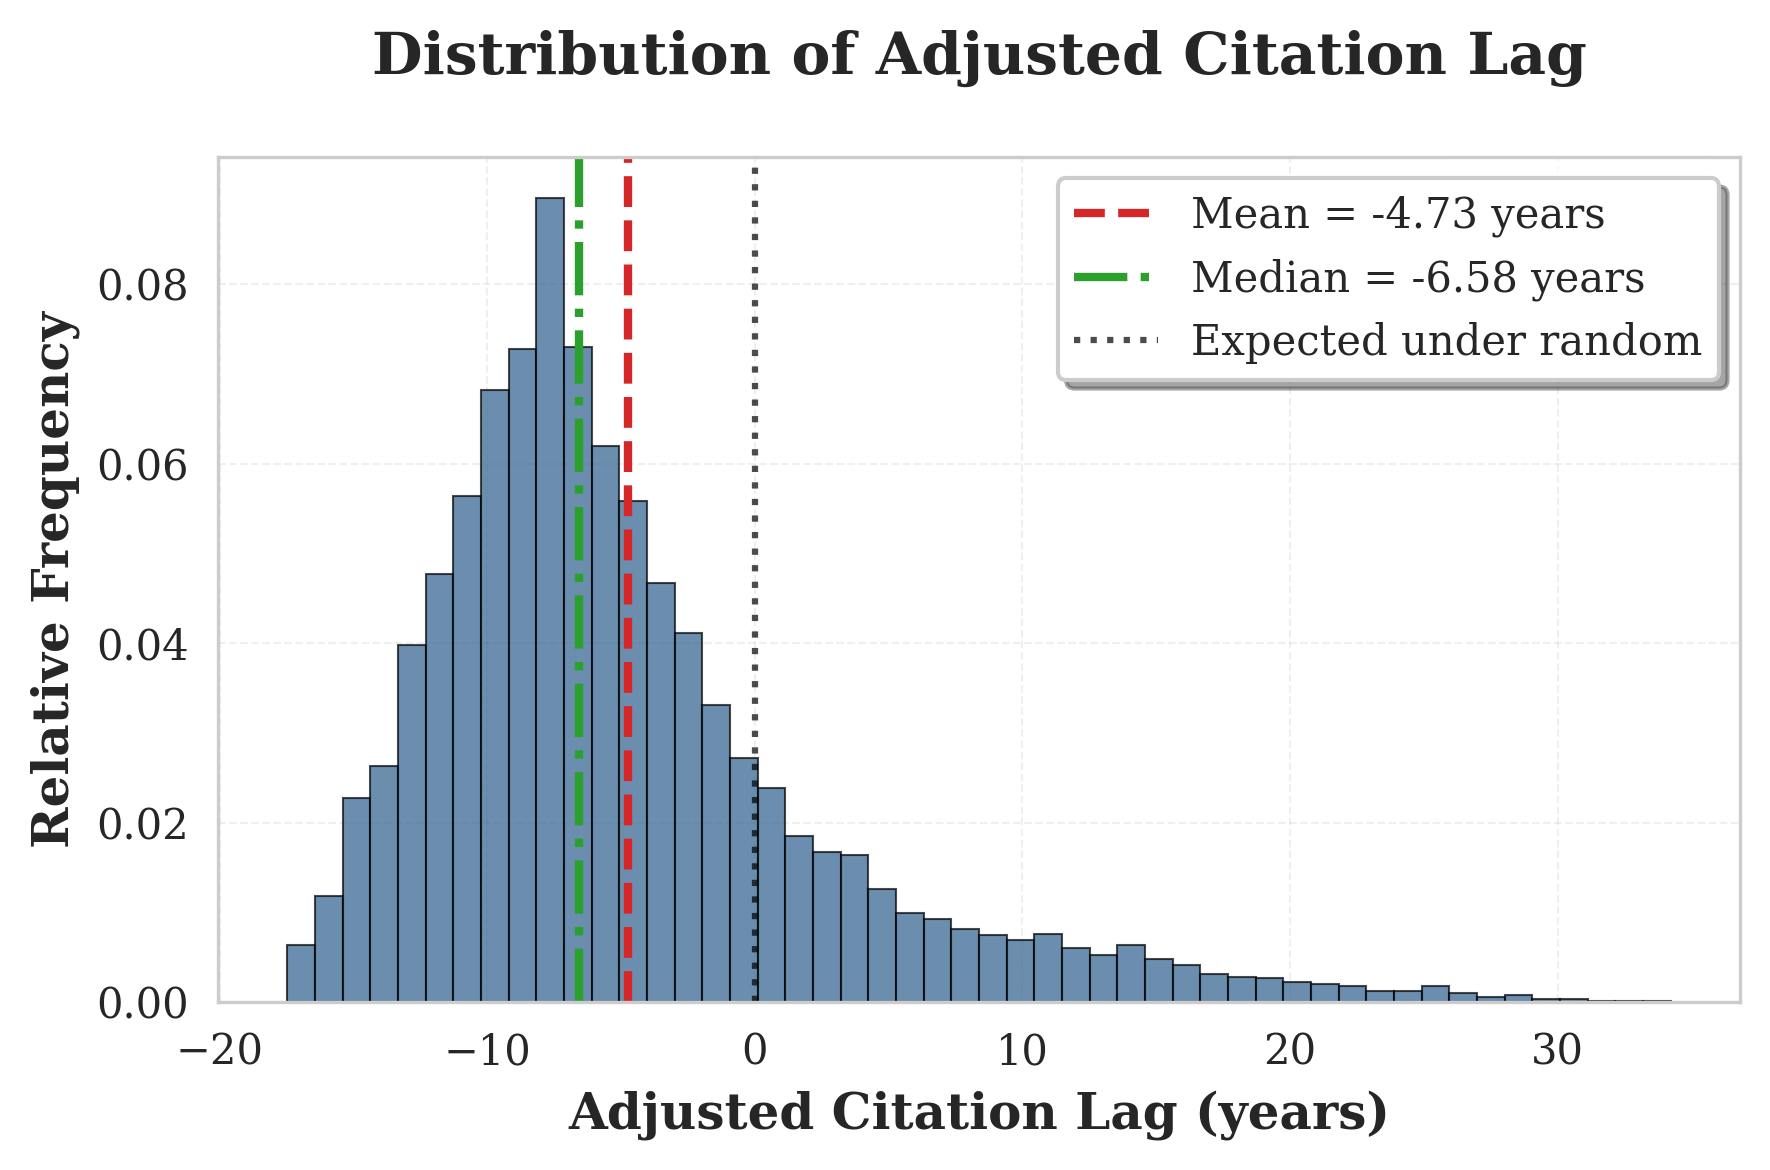


ADJUSTED CITATION LAG: SUMMARY STATISTICS
Sample size (N):          110,179
Mean:                     -4.73 years
Standard deviation:       7.68 years
Median:                   -6.58 years
10th percentile:          -12.49 years
25th percentile (Q1):     -9.76 years
75th percentile (Q3):     -1.76 years
90th percentile:          5.51 years
Minimum:                  -17.47 years
Maximum:                  34.23 years

INTERPRETATION:
Adjusted lag < 0: citations to MORE RECENT decisions than expected
Adjusted lag > 0: citations to OLDER decisions than expected



In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set academic style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10

# Citation lag in years (only when both dates present)
mask_dates = df["DATE_FROM"].notna() & df["DATE_TO"].notna()
citing_dates = df.loc[mask_dates, "DATE_FROM"]
cited_dates = df.loc[mask_dates, "DATE_TO"]

# Filter to valid citations for adjusted analysis
valid_mask = (citing_dates - cited_dates).dt.days / 365.25 >= 0
citing_years = citing_dates[valid_mask].dt.year
cited_years = cited_dates[valid_mask].dt.year

# Count judgments per year (for the pool of citable decisions)
all_judgment_years = df["DATE_TO"].dropna().dt.year
judgments_per_year = Counter(all_judgment_years)

# Compute expected citation lag under random model
expected_lags = []
observed_lags = []

for citing_yr, cited_yr in zip(citing_years, cited_years):
    lag = citing_yr - cited_yr
    observed_lags.append(lag)
    
    # Pool of available judgments: all years up to and including citing year
    available_years = {yr: count for yr, count in judgments_per_year.items() if yr <= citing_yr}
    total_available = sum(available_years.values())
    
    if total_available > 0:
        # Expected lag under random citation
        expected_lag = sum((citing_yr - yr) * (count / total_available) 
                          for yr, count in available_years.items())
        expected_lags.append(expected_lag)
    else:
        expected_lags.append(np.nan)

observed_lags = np.array(observed_lags)
expected_lags = np.array(expected_lags)

# Adjusted lag: observed - expected (negative = citing newer than expected)
adjusted_lags = observed_lags - expected_lags
adjusted_lags = adjusted_lags[~np.isnan(adjusted_lags)]

# Summary statistics
def compute_summary(data, name):
    return {
        "name": name,
        "count": int(len(data)),
        "mean": float(np.mean(data)) if len(data) else np.nan,
        "median": float(np.median(data)) if len(data) else np.nan,
        "std": float(np.std(data)) if len(data) else np.nan,
        "p10": float(np.percentile(data, 10)) if len(data) else np.nan,
        "p25": float(np.percentile(data, 25)) if len(data) else np.nan,
        "p75": float(np.percentile(data, 75)) if len(data) else np.nan,
        "p90": float(np.percentile(data, 90)) if len(data) else np.nan,
        "max": float(np.max(data)) if len(data) else np.nan,
        "min": float(np.min(data)) if len(data) else np.nan,
    }

adjusted_summary = compute_summary(adjusted_lags, "Adjusted Citation Lag")

# Create figure
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Adjusted citation lag histogram
bins_adj = 50
ax.hist(adjusted_lags, bins=bins_adj, density=True, color='#2C5F8D', alpha=0.7, 
        edgecolor='black', linewidth=0.5)

mean_adj = np.mean(adjusted_lags)
median_adj = np.median(adjusted_lags)
ax.axvline(mean_adj, color='#D62728', linestyle='--', linewidth=2, 
           label=f'Mean = {mean_adj:.2f} years')
ax.axvline(median_adj, color='#2CA02C', linestyle='-.', linewidth=2, 
           label=f'Median = {median_adj:.2f} years')
ax.axvline(0, color='black', linestyle=':', linewidth=1.5, alpha=0.7,
           label='Expected under random')

ax.set_xlabel('Adjusted Citation Lag (years)', fontsize=12, fontweight='bold')
ax.set_ylabel('Relative Frequency', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Adjusted Citation Lag', fontsize=14, fontweight='bold', pad=20)
ax.text(0.98, 0.98, f'n = {len(adjusted_lags):,}', transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('adjusted_citation_lag.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("ADJUSTED CITATION LAG: SUMMARY STATISTICS")
print("="*60)
print(f"Sample size (N):          {adjusted_summary['count']:,}")
print(f"Mean:                     {adjusted_summary['mean']:.2f} years")
print(f"Standard deviation:       {adjusted_summary['std']:.2f} years")
print(f"Median:                   {adjusted_summary['median']:.2f} years")
print(f"10th percentile:          {adjusted_summary['p10']:.2f} years")
print(f"25th percentile (Q1):     {adjusted_summary['p25']:.2f} years")
print(f"75th percentile (Q3):     {adjusted_summary['p75']:.2f} years")
print(f"90th percentile:          {adjusted_summary['p90']:.2f} years")
print(f"Minimum:                  {adjusted_summary['min']:.2f} years")
print(f"Maximum:                  {adjusted_summary['max']:.2f} years")
print("="*60)
print("\nINTERPRETATION:")
print("Adjusted lag < 0: citations to MORE RECENT decisions than expected")
print("Adjusted lag > 0: citations to OLDER decisions than expected")
print("="*60 + "\n")

FUNCTION FITTING COMPARISON
Function                      SSE   Parameters
-----------------------------------------------------------------
Shifted Log-Normal       0.000769   A=1.00, μ=2.69, σ=0.38, shift=-21.36
Shifted Gamma            0.000794   A=0.00, k=7.48, θ=1.98, shift=-20.99
Asymmetric Gaussian      0.000959   A=0.07, μ=-8.63, σ_L=3.76, σ_R=6.36
Gaussian                 0.001329   A=0.07, μ=-7.34, σ=4.97
-----------------------------------------------------------------
Best fit: Shifted Log-Normal


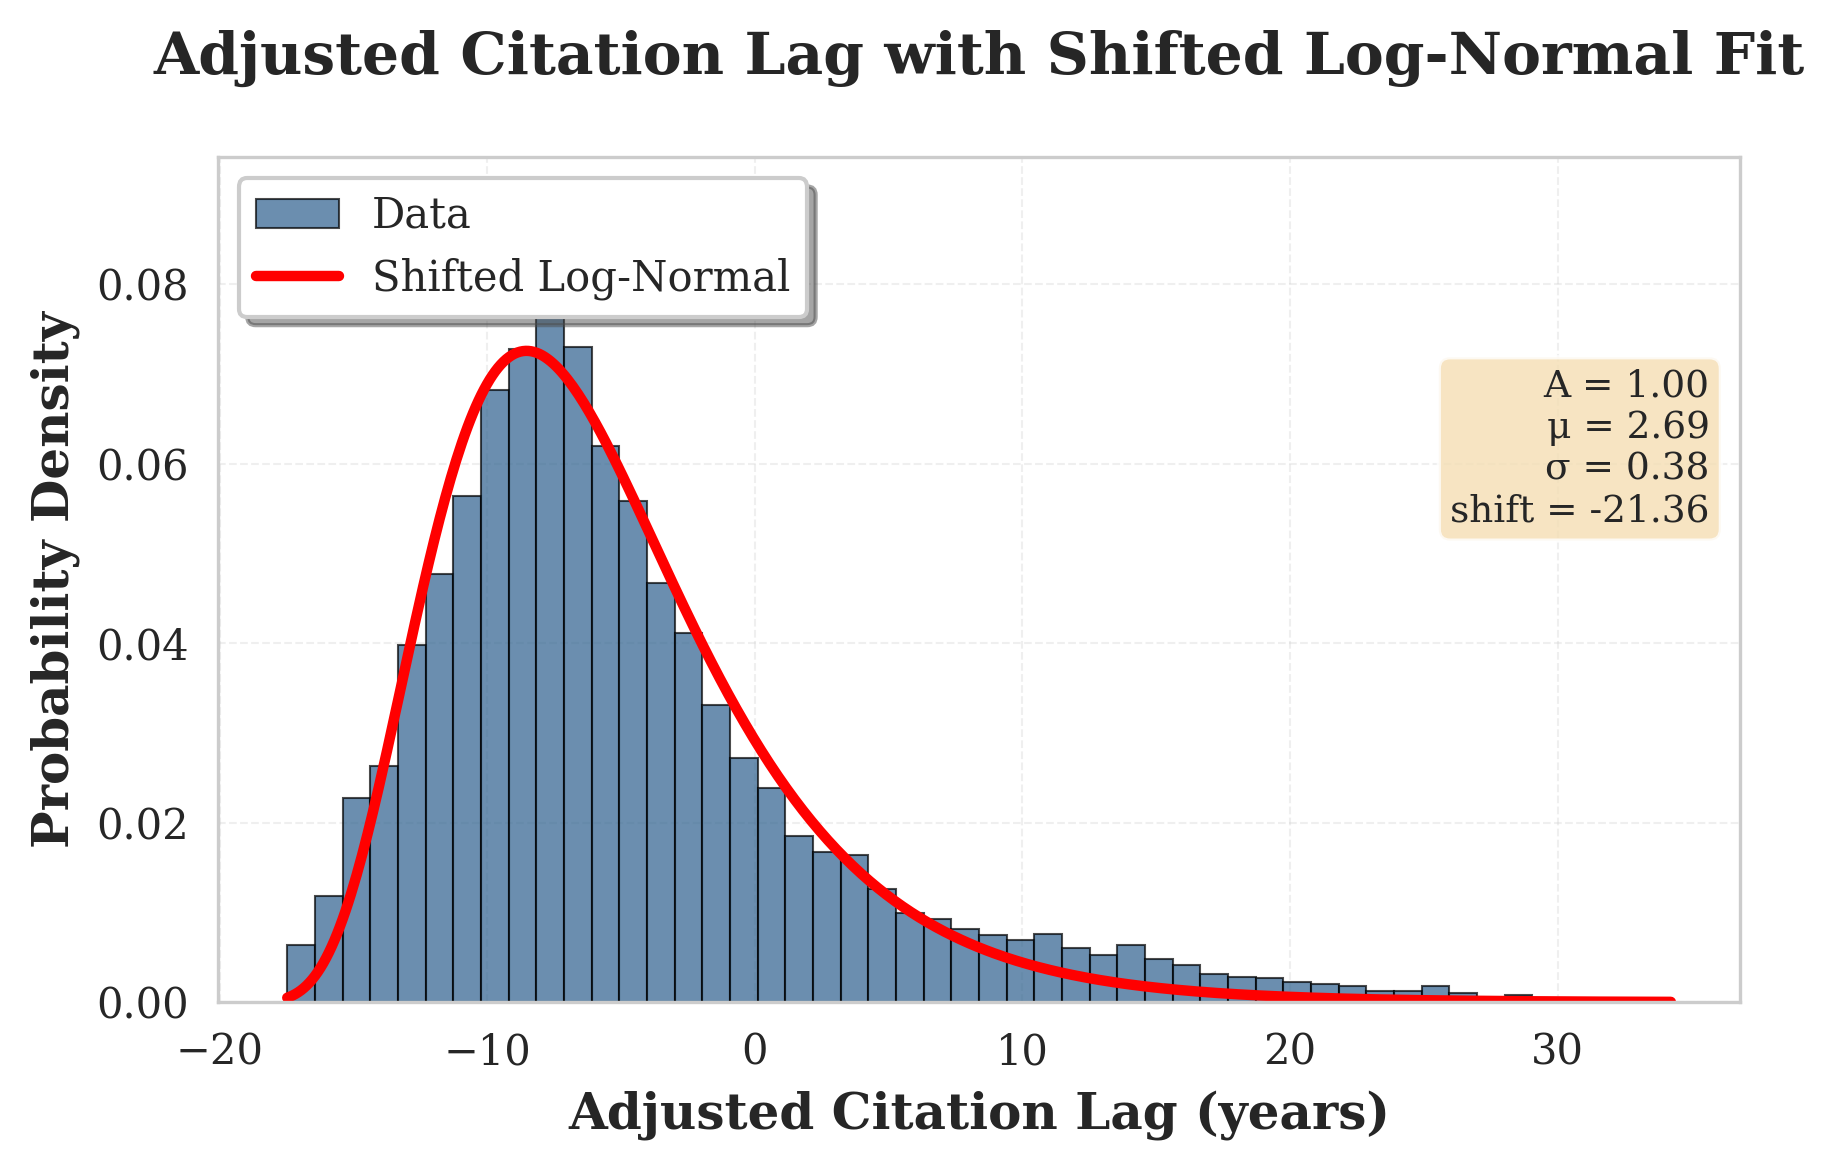

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/christianjensen/Documents/Master-Thesis/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "/Users/christianjensen/Documents/Master-Thesis/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py", line 302, in dispatch_control
    await self.process_control(msg)
  File "/Users/christianjensen/Documents/Master-Thesis/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py", line 308, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
                  ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/Users/christianjensen/Documents/Master-Thesis/.venv/lib/python3.13/site-packages/jupyter_client/session.py", line 994, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Trac

In [29]:
from scipy.optimize import curve_fit
from scipy.special import gamma as gamma_func

# Define standard functions to fit

# 1. Gaussian
def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu)**2) / (2 * sigma**2))

# 2. Asymmetric Gaussian (split Gaussian)
def asymmetric_gaussian(x, A, mu, sigma_L, sigma_R):
    result = np.zeros_like(x)
    left = x < mu
    right = ~left
    result[left] = A * np.exp(-((x[left] - mu)**2) / (2 * sigma_L**2))
    result[right] = A * np.exp(-((x[right] - mu)**2) / (2 * sigma_R**2))
    return result

# 3. Shifted Log-Normal: shift data so x-shift > 0
def shifted_lognormal(x, A, mu, sigma, shift):
    z = x - shift
    result = np.zeros_like(x, dtype=float)
    valid = z > 0
    result[valid] = A * np.exp(-((np.log(z[valid]) - mu)**2) / (2 * sigma**2)) / z[valid]
    return result

# 4. Shifted Gamma
def shifted_gamma(x, A, k, theta, shift):
    z = x - shift
    result = np.zeros_like(x, dtype=float)
    valid = z > 0
    result[valid] = A * (z[valid]**(k-1)) * np.exp(-z[valid]/theta)
    return result

# Get histogram data for fitting
hist_counts, bin_edges = np.histogram(adjusted_lags, bins=50, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Initial guesses
mu_init = np.median(adjusted_lags)
sigma_init = np.std(adjusted_lags)
A_init = hist_counts.max()
shift_init = adjusted_lags.min() - 1  # Shift to make all values positive

fit_results = {}

# Fit Gaussian
try:
    popt, _ = curve_fit(gaussian, bin_centers, hist_counts, 
                        p0=[A_init, mu_init, sigma_init], maxfev=5000)
    fit = gaussian(bin_centers, *popt)
    sse = np.sum((hist_counts - fit)**2)
    fit_results['Gaussian'] = {'params': popt, 'sse': sse, 'func': gaussian,
                               'labels': ['A', 'μ', 'σ']}
except Exception as e:
    print(f"Gaussian fit failed: {e}")

# Fit Asymmetric Gaussian
try:
    popt, _ = curve_fit(asymmetric_gaussian, bin_centers, hist_counts,
                        p0=[A_init, mu_init, sigma_init/2, sigma_init], maxfev=5000)
    fit = asymmetric_gaussian(bin_centers, *popt)
    sse = np.sum((hist_counts - fit)**2)
    fit_results['Asymmetric Gaussian'] = {'params': popt, 'sse': sse, 'func': asymmetric_gaussian,
                                          'labels': ['A', 'μ', 'σ_L', 'σ_R']}
except Exception as e:
    print(f"Asymmetric Gaussian fit failed: {e}")

# Fit Shifted Log-Normal
try:
    popt, _ = curve_fit(shifted_lognormal, bin_centers, hist_counts,
                        p0=[A_init * 5, 2, 0.5, shift_init],
                        bounds=([0, -10, 0.01, -50], [1, 10, 5, shift_init + 5]),
                        maxfev=10000)
    fit = shifted_lognormal(bin_centers, *popt)
    sse = np.sum((hist_counts - fit)**2)
    fit_results['Shifted Log-Normal'] = {'params': popt, 'sse': sse, 'func': shifted_lognormal,
                                         'labels': ['A', 'μ', 'σ', 'shift']}
except Exception as e:
    print(f"Shifted Log-Normal fit failed: {e}")

# Fit Shifted Gamma
try:
    popt, _ = curve_fit(shifted_gamma, bin_centers, hist_counts,
                        p0=[0.01, 3, 5, shift_init],
                        bounds=([0, 0.5, 0.1, -50], [1, 20, 50, shift_init + 5]),
                        maxfev=10000)
    fit = shifted_gamma(bin_centers, *popt)
    sse = np.sum((hist_counts - fit)**2)
    fit_results['Shifted Gamma'] = {'params': popt, 'sse': sse, 'func': shifted_gamma,
                                    'labels': ['A', 'k', 'θ', 'shift']}
except Exception as e:
    print(f"Shifted Gamma fit failed: {e}")

# Print results
print("="*65)
print("FUNCTION FITTING COMPARISON")
print("="*65)
print(f"{'Function':<22} {'SSE':>10}   Parameters")
print("-"*65)
for name, res in sorted(fit_results.items(), key=lambda x: x[1]['sse']):
    params_str = ', '.join([f'{l}={p:.2f}' for l, p in zip(res['labels'], res['params'])])
    print(f"{name:<22} {res['sse']:>10.6f}   {params_str}")
print("-"*65)

best_name = min(fit_results, key=lambda x: fit_results[x]['sse'])
print(f"Best fit: {best_name}")
print("="*65)

# Plot with best fit
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

ax.hist(adjusted_lags, bins=50, density=True, color='#2C5F8D', alpha=0.7, 
        edgecolor='black', linewidth=0.5, label='Data')

x_range = np.linspace(adjusted_lags.min(), adjusted_lags.max(), 500)

best_res = fit_results[best_name]
y_fit = best_res['func'](x_range, *best_res['params'])
param_text = '\n'.join([f'{l} = {p:.2f}' for l, p in zip(best_res['labels'], best_res['params'])])

ax.plot(x_range, y_fit, 'r-', linewidth=2.5, label=best_name)

ax.text(0.98, 0.75, param_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_xlabel('Adjusted Citation Lag (years)', fontsize=12, fontweight='bold')
ax.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax.set_title(f'Adjusted Citation Lag with {best_name} Fit', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('adjusted_citation_lag_fitted.png', dpi=300, bbox_inches='tight')
plt.show()

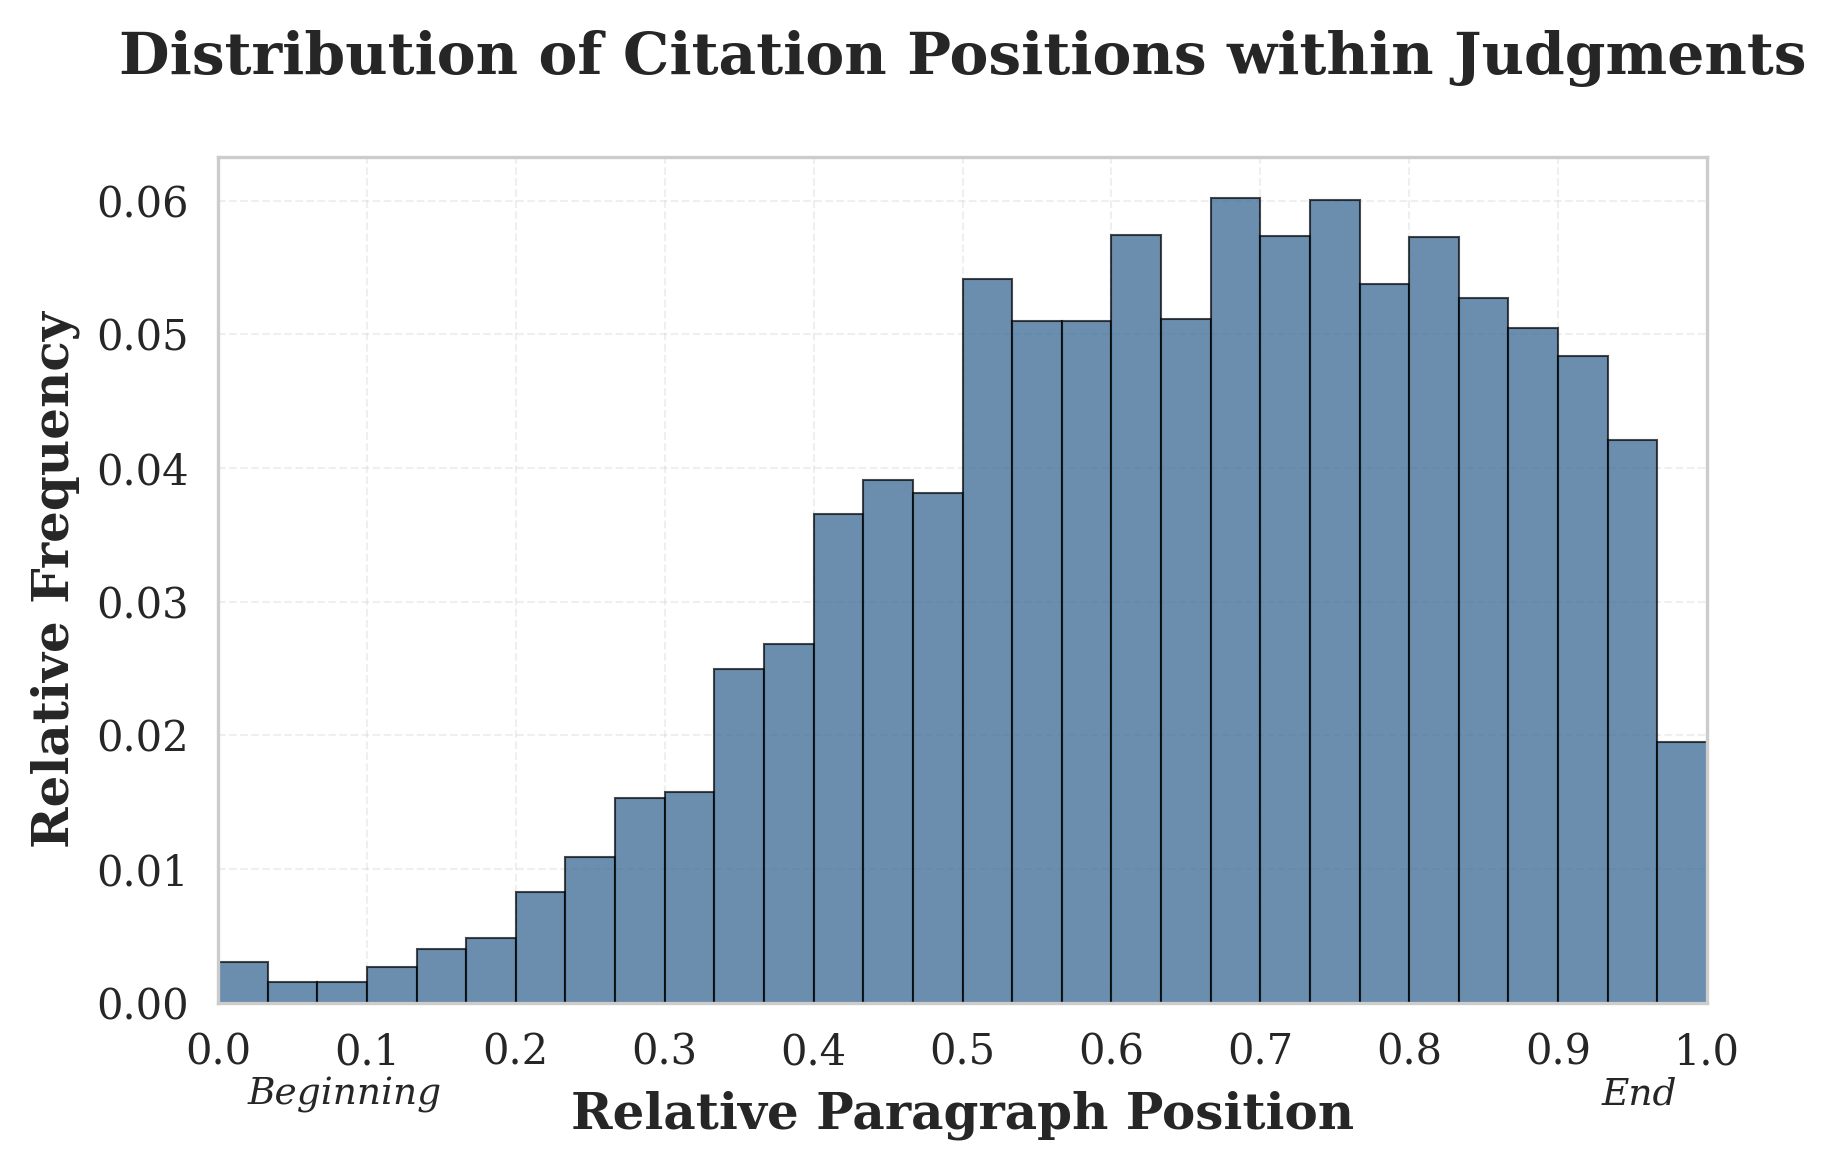


CITATION POSITION ANALYSIS: SUMMARY STATISTICS
Sample size (N):          110,179
Mean:                     0.648
Standard deviation:       0.201
Median:                   0.667
10th percentile:          0.375
25th percentile (Q1):     0.505
75th percentile (Q3):     0.810
90th percentile:          0.906



In [18]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set academic style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10

# Load judgments_cleaned to get actual paragraph counts
with open("../data/judgments.json", "r", encoding="utf-8") as f:
    judgments_cleaned = json.load(f)

# Create a mapping from CELEX to actual max paragraph number
celex_to_max_para = {}
for celex_id, judgment in judgments_cleaned.items():
    if celex_id and "paragraphs" in judgment:
        # Get the maximum paragraph number from the paragraphs dict
        para_nums = [int(k) for k in judgment["paragraphs"].keys() if k.isdigit()]
        if para_nums:
            celex_to_max_para[celex_id] = max(para_nums)

# Map to dataframe
df["MAX_PARA_TO"] = df["CELEX_TO"].map(celex_to_max_para)

# Normalize NUMBER_TO by actual max paragraph count from judgments_cleaned
df["NUMBER_TO_RATIO"] = df["NUMBER_TO"] / df["MAX_PARA_TO"]

# Filter out NaN values for analysis
ratios = df["NUMBER_TO_RATIO"].dropna()

# Summary statistics
ratio_summary = {
    "count": int(ratios.shape[0]),
    "mean": float(ratios.mean()) if ratios.shape[0] else np.nan,
    "median": float(ratios.median()) if ratios.shape[0] else np.nan,
    "std": float(ratios.std()) if ratios.shape[0] else np.nan,
    "p10": float(ratios.quantile(0.10)) if ratios.shape[0] else np.nan,
    "p25": float(ratios.quantile(0.25)) if ratios.shape[0] else np.nan,
    "p75": float(ratios.quantile(0.75)) if ratios.shape[0] else np.nan,
    "p90": float(ratios.quantile(0.90)) if ratios.shape[0] else np.nan,
}

# Create figure
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Histogram with density normalization
weights = np.ones_like(ratios) / len(ratios)
n, bins_edges, patches = ax.hist(ratios, bins=30, range=(0, 1), 
                                   weights=weights,
                                   color='#2C5F8D', alpha=0.7, 
                                   edgecolor='black', linewidth=0.5)

# Labels and title
ax.set_xlabel('Relative Paragraph Position', fontsize=12, fontweight='bold')
ax.set_ylabel('Relative Frequency', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Citation Positions within Judgments', 
             fontsize=14, fontweight='bold', pad=20)

# Set x-axis ticks
ax.set_xticks([i/10 for i in range(11)])
ax.set_xlim(0, 1)

# Add position labels
ax.text(0.02, -0.12, 'Beginning', transform=ax.transAxes, 
        fontsize=9, style='italic', ha='left')
ax.text(0.98, -0.12, 'End', transform=ax.transAxes, 
        fontsize=9, style='italic', ha='right')


# Grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Print summary statistics in academic format
print("\n" + "="*60)
print("CITATION POSITION ANALYSIS: SUMMARY STATISTICS")
print("="*60)
print(f"Sample size (N):          {ratio_summary['count']:,}")
print(f"Mean:                     {ratio_summary['mean']:.3f}")
print(f"Standard deviation:       {ratio_summary['std']:.3f}")
print(f"Median:                   {ratio_summary['median']:.3f}")
print(f"10th percentile:          {ratio_summary['p10']:.3f}")
print(f"25th percentile (Q1):     {ratio_summary['p25']:.3f}")
print(f"75th percentile (Q3):     {ratio_summary['p75']:.3f}")
print(f"90th percentile:          {ratio_summary['p90']:.3f}")
print("="*60 + "\n")

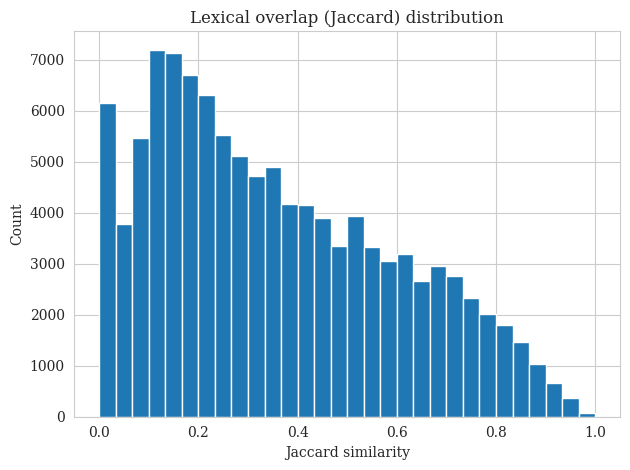

,mean,median,p10,p90
0,0.355594,0.310345,0.074074,0.716667


In [19]:
import numpy as np
from nltk.tokenize import word_tokenize

sub = df.dropna(subset=["TEXT_FROM", "TEXT_TO"]).copy()

# Tokenization using nltk
def tokenize(s: str) -> list[str]:
    return [t.lower() for t in word_tokenize(s) if t.isalpha() and len(t) > 2]

def jaccard(a, b):
    sa, sb = set(a), set(b)
    if not sa and not sb:
        return np.nan
    return len(sa & sb) / len(sa | sb)

# Compute Jaccard similarity per edge (this is a rough lexical measure)
jac = []
for t_from, t_to in zip(sub["TEXT_FROM"], sub["TEXT_TO"]):
    tf = tokenize(t_from)
    tt = tokenize(t_to)
    jac.append(jaccard(tf, tt))

sub["jaccard"] = jac

# Plot histogram
plt.figure()
plt.hist([x for x in sub["jaccard"].values if pd.notna(x)], bins=30)
plt.title("Lexical overlap (Jaccard) distribution")
plt.xlabel("Jaccard similarity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

summary = {
    "mean": float(np.nanmean(sub["jaccard"])) if len(sub) else np.nan,
    "median": float(np.nanmedian(sub["jaccard"])) if len(sub) else np.nan,
    "p10": float(np.nanpercentile(sub["jaccard"], 10)) if len(sub) else np.nan,
    "p90": float(np.nanpercentile(sub["jaccard"], 90)) if len(sub) else np.nan,
}

pd.DataFrame([summary])

Cases with valid duration data: 30,566


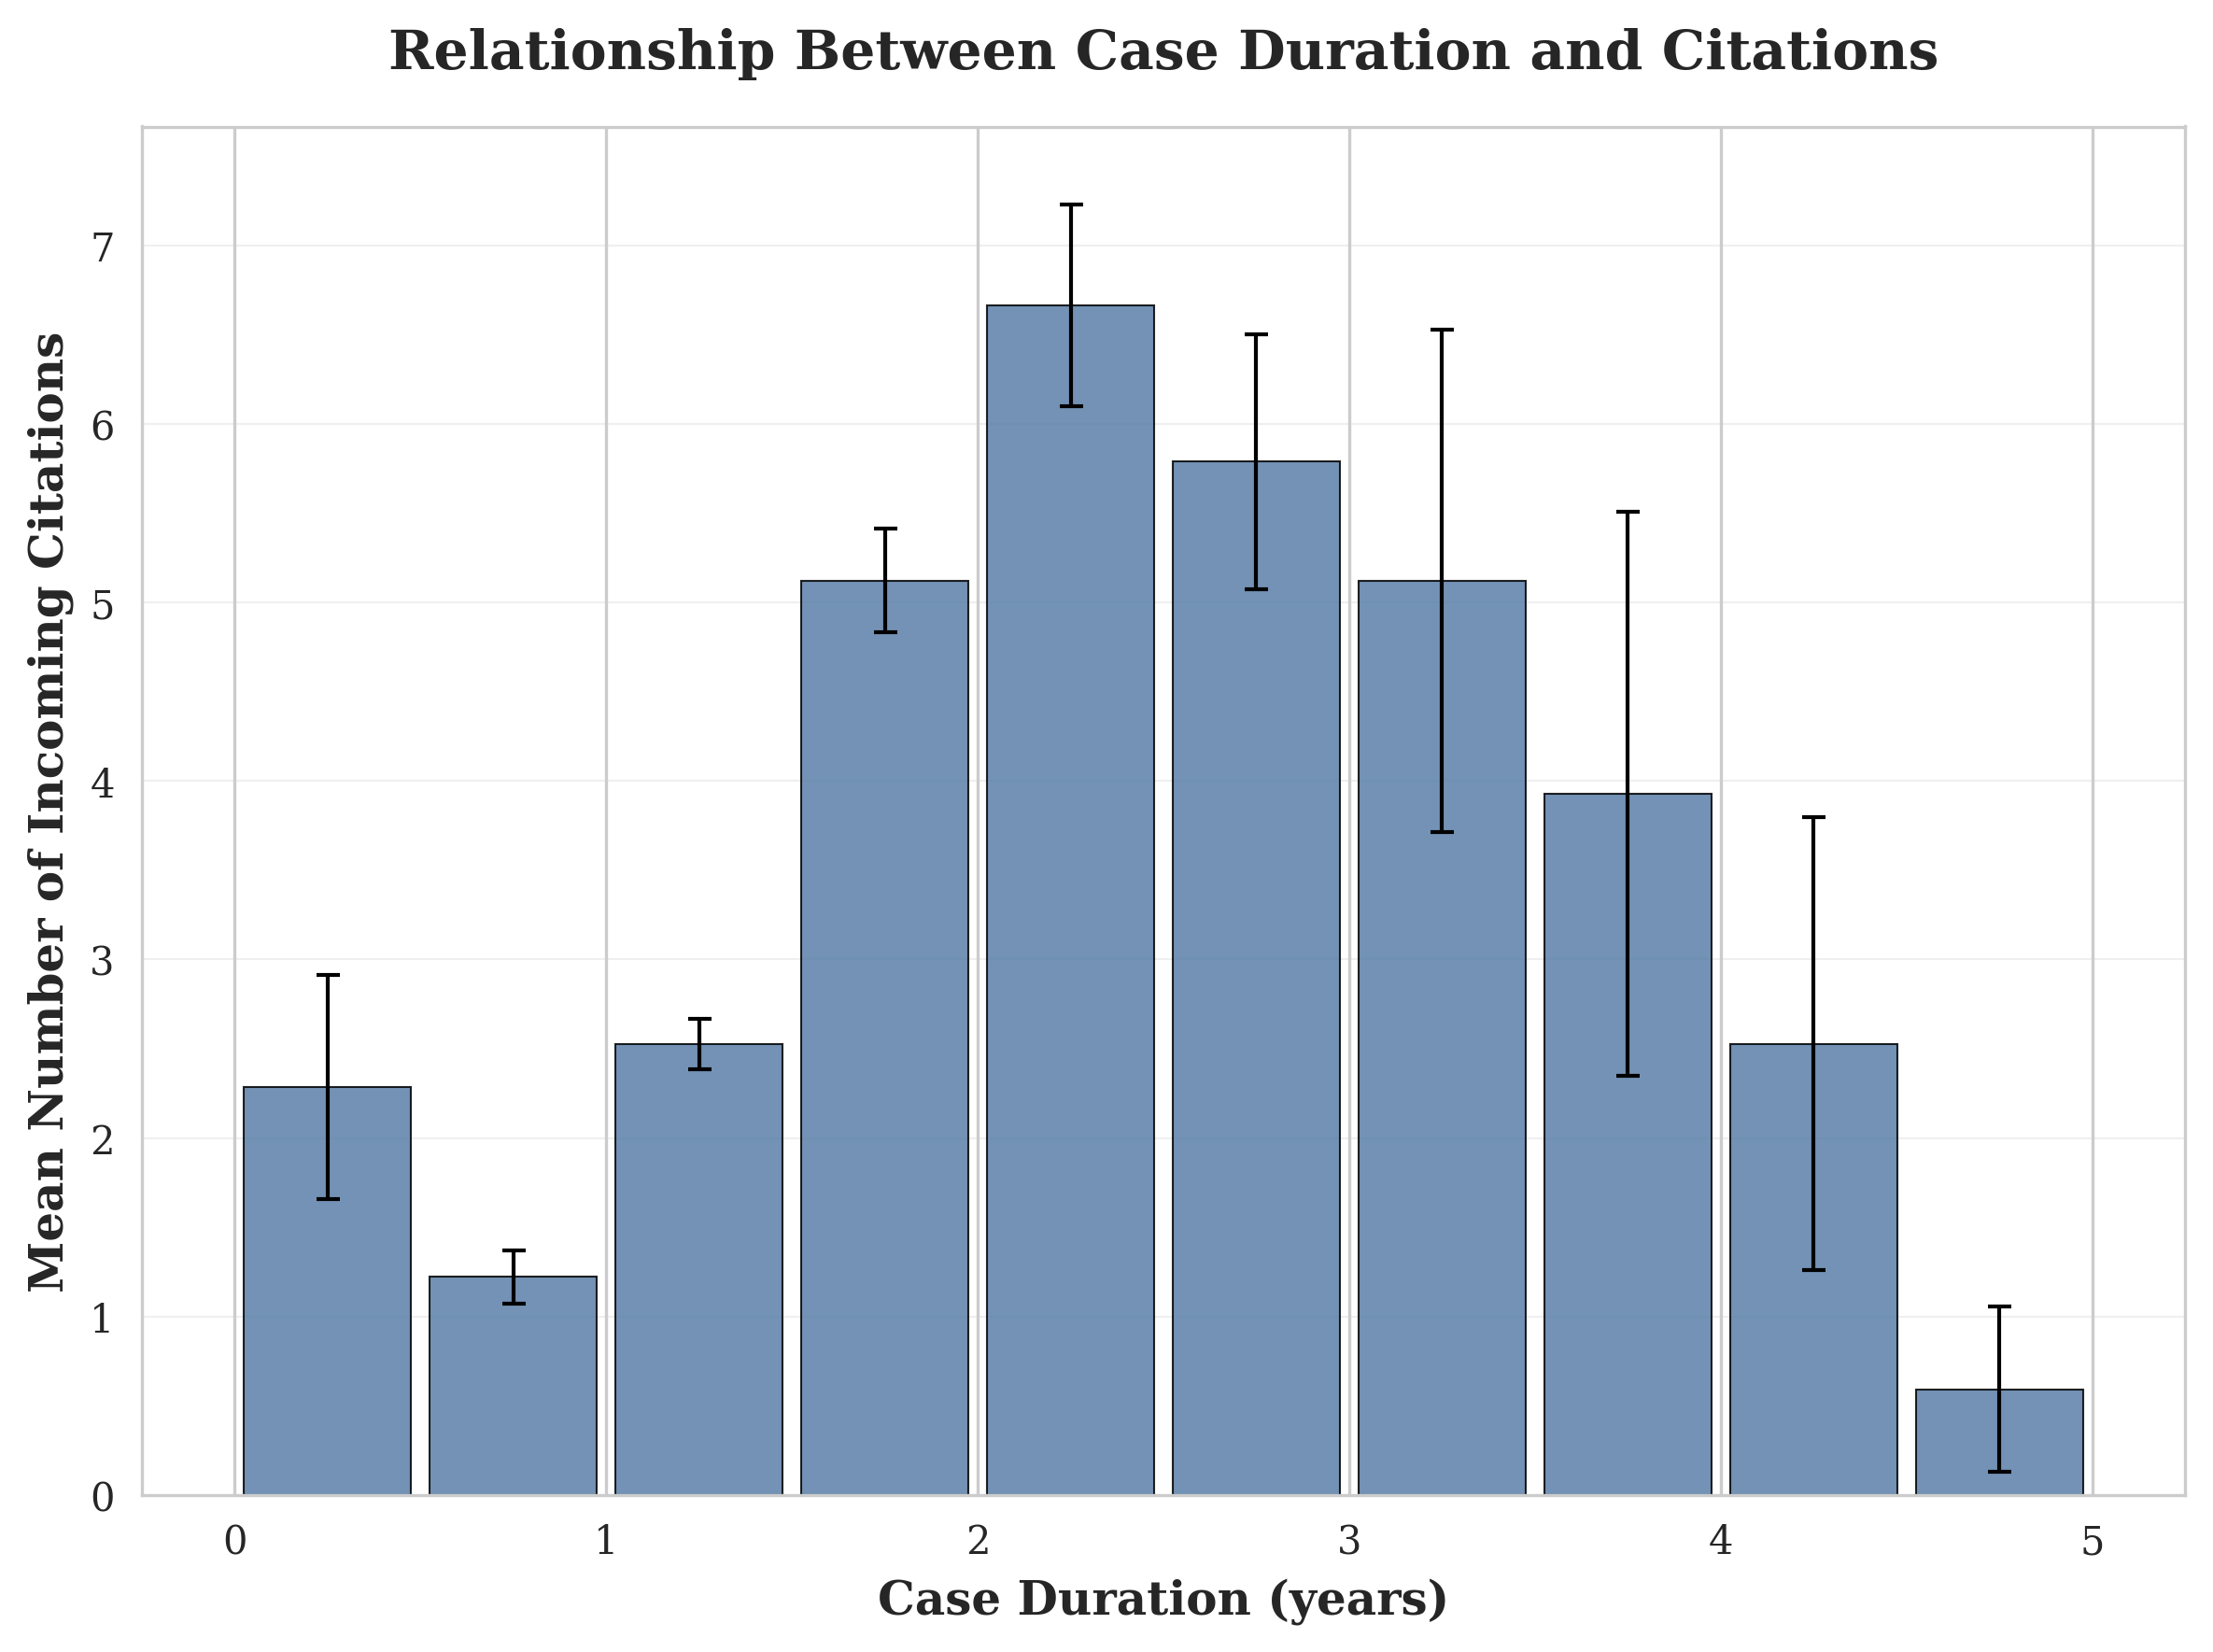


DURATION VS CITATIONS: SUMMARY BY BIN
0.0-0.5 years: n=  833, mean=2.29 ± 0.63 (95% CI)
0.5-1.0 years: n=5,004, mean=1.22 ± 0.15 (95% CI)
1.0-1.5 years: n=11,056, mean=2.53 ± 0.14 (95% CI)
1.5-2.0 years: n=7,270, mean=5.12 ± 0.29 (95% CI)
2.0-2.5 years: n=3,260, mean=6.66 ± 0.56 (95% CI)
2.5-3.0 years: n=1,479, mean=5.79 ± 0.71 (95% CI)
3.0-3.5 years: n=  762, mean=5.12 ± 1.41 (95% CI)
3.5-4.0 years: n=  439, mean=3.93 ± 1.58 (95% CI)
4.0-4.5 years: n=  276, mean=2.53 ± 1.27 (95% CI)
4.5-5.0 years: n=  187, mean=0.59 ± 0.46 (95% CI)


In [30]:
# ============================================================================
# CASE DURATION VS CITATIONS ANALYSIS (Academic Style)
# ============================================================================

import json
from collections import defaultdict
from datetime import datetime
from pathlib import Path
from scipy import stats

# Set academic style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10

# Load case metadata
json_path = Path("../data/par-to-par.json")
with open(json_path, "r", encoding="utf-8") as f:
    case_data = json.load(f)

# Compute duration for each case
def compute_duration_days(application_date_str: str | None, date_str: str | None) -> int | None:
    if not application_date_str or not date_str:
        return None
    try:
        app_date = datetime.strptime(application_date_str, "%Y-%m-%d")
        case_date = datetime.strptime(date_str, "%Y-%m-%d")
        return (case_date - app_date).days
    except (ValueError, TypeError):
        return None

case_durations: dict[str, int] = {}
for celex, case in case_data.items():
    meta = case.get("meta", {})
    duration = compute_duration_days(meta.get("application_date"), meta.get("date"))
    if duration is not None and duration >= 0:
        case_durations[celex] = duration

# Count citations per case (incoming citations)
case_citation_counts: dict[str, int] = defaultdict(int)
for celex_to in df["CELEX_TO"]:
    case_citation_counts[celex_to] += 1

# Build arrays
durations = np.array([case_durations[c] for c in case_durations])
citations = np.array([case_citation_counts.get(c, 0) for c in case_durations])

# Cap at 5 years
max_duration_years = 5
max_days = int(max_duration_years * 365)
mask = durations <= max_days
durations_capped = durations[mask] / 365  # Convert to years
citations_capped = citations[mask]

print(f"Cases with valid duration data: {len(durations_capped):,}")

# Create 0.5-year bins
bin_edges = np.arange(0, max_duration_years + 0.5, 0.5)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Compute mean and 95% CI for each bin
mean_citations = []
ci_95 = []
counts = []

for i in range(len(bin_edges) - 1):
    bin_mask = (durations_capped >= bin_edges[i]) & (durations_capped < bin_edges[i + 1])
    bin_citations = citations_capped[bin_mask]
    n = len(bin_citations)
    counts.append(n)
    if n > 1:
        mean_citations.append(np.mean(bin_citations))
        sem = stats.sem(bin_citations)
        t_crit = stats.t.ppf(0.975, df=n - 1)  # 95% CI uses 0.975 for two-tailed
        ci_95.append(t_crit * sem)
    else:
        mean_citations.append(0 if n == 0 else bin_citations[0])
        ci_95.append(0)

mean_citations = np.array(mean_citations)
ci_95 = np.array(ci_95)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Bar plot with error bars
bars = ax.bar(bin_centers, mean_citations, width=0.45, 
              color='#5A7FA8', edgecolor='black', linewidth=0.5, alpha=0.85)

# Add error bars (95% CI)
ax.errorbar(bin_centers, mean_citations, yerr=ci_95, 
            fmt='none', ecolor='black', capsize=3, capthick=1, linewidth=1)

# Labels and title
ax.set_xlabel('Case Duration (years)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Number of Incoming Citations', fontsize=12, fontweight='bold')
ax.set_title('Relationship Between Case Duration and Citations', 
             fontsize=14, fontweight='bold', pad=15)

# Set axis limits
ax.set_xlim(-0.25, max_duration_years + 0.25)
ax.set_ylim(0, max(mean_citations) * 1.15)

# Grid
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, axis='y')
ax.set_axisbelow(True)

# X-axis ticks
ax.set_xticks(range(0, max_duration_years + 1))

plt.tight_layout()

# Save figure
output_path = Path("../artifacts")
output_path.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path / "duration_citations_academic.png", dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

plt.show()

# Print statistics
print(f"\n{'='*50}")
print("DURATION VS CITATIONS: SUMMARY BY BIN")
print(f"{'='*50}")
for i, (center, mean, ci, n) in enumerate(zip(bin_centers, mean_citations, ci_95, counts)):
    print(f"{bin_edges[i]:.1f}-{bin_edges[i+1]:.1f} years: n={n:5,}, mean={mean:.2f} ± {ci:.2f} (95% CI)")
print(f"{'='*50}")

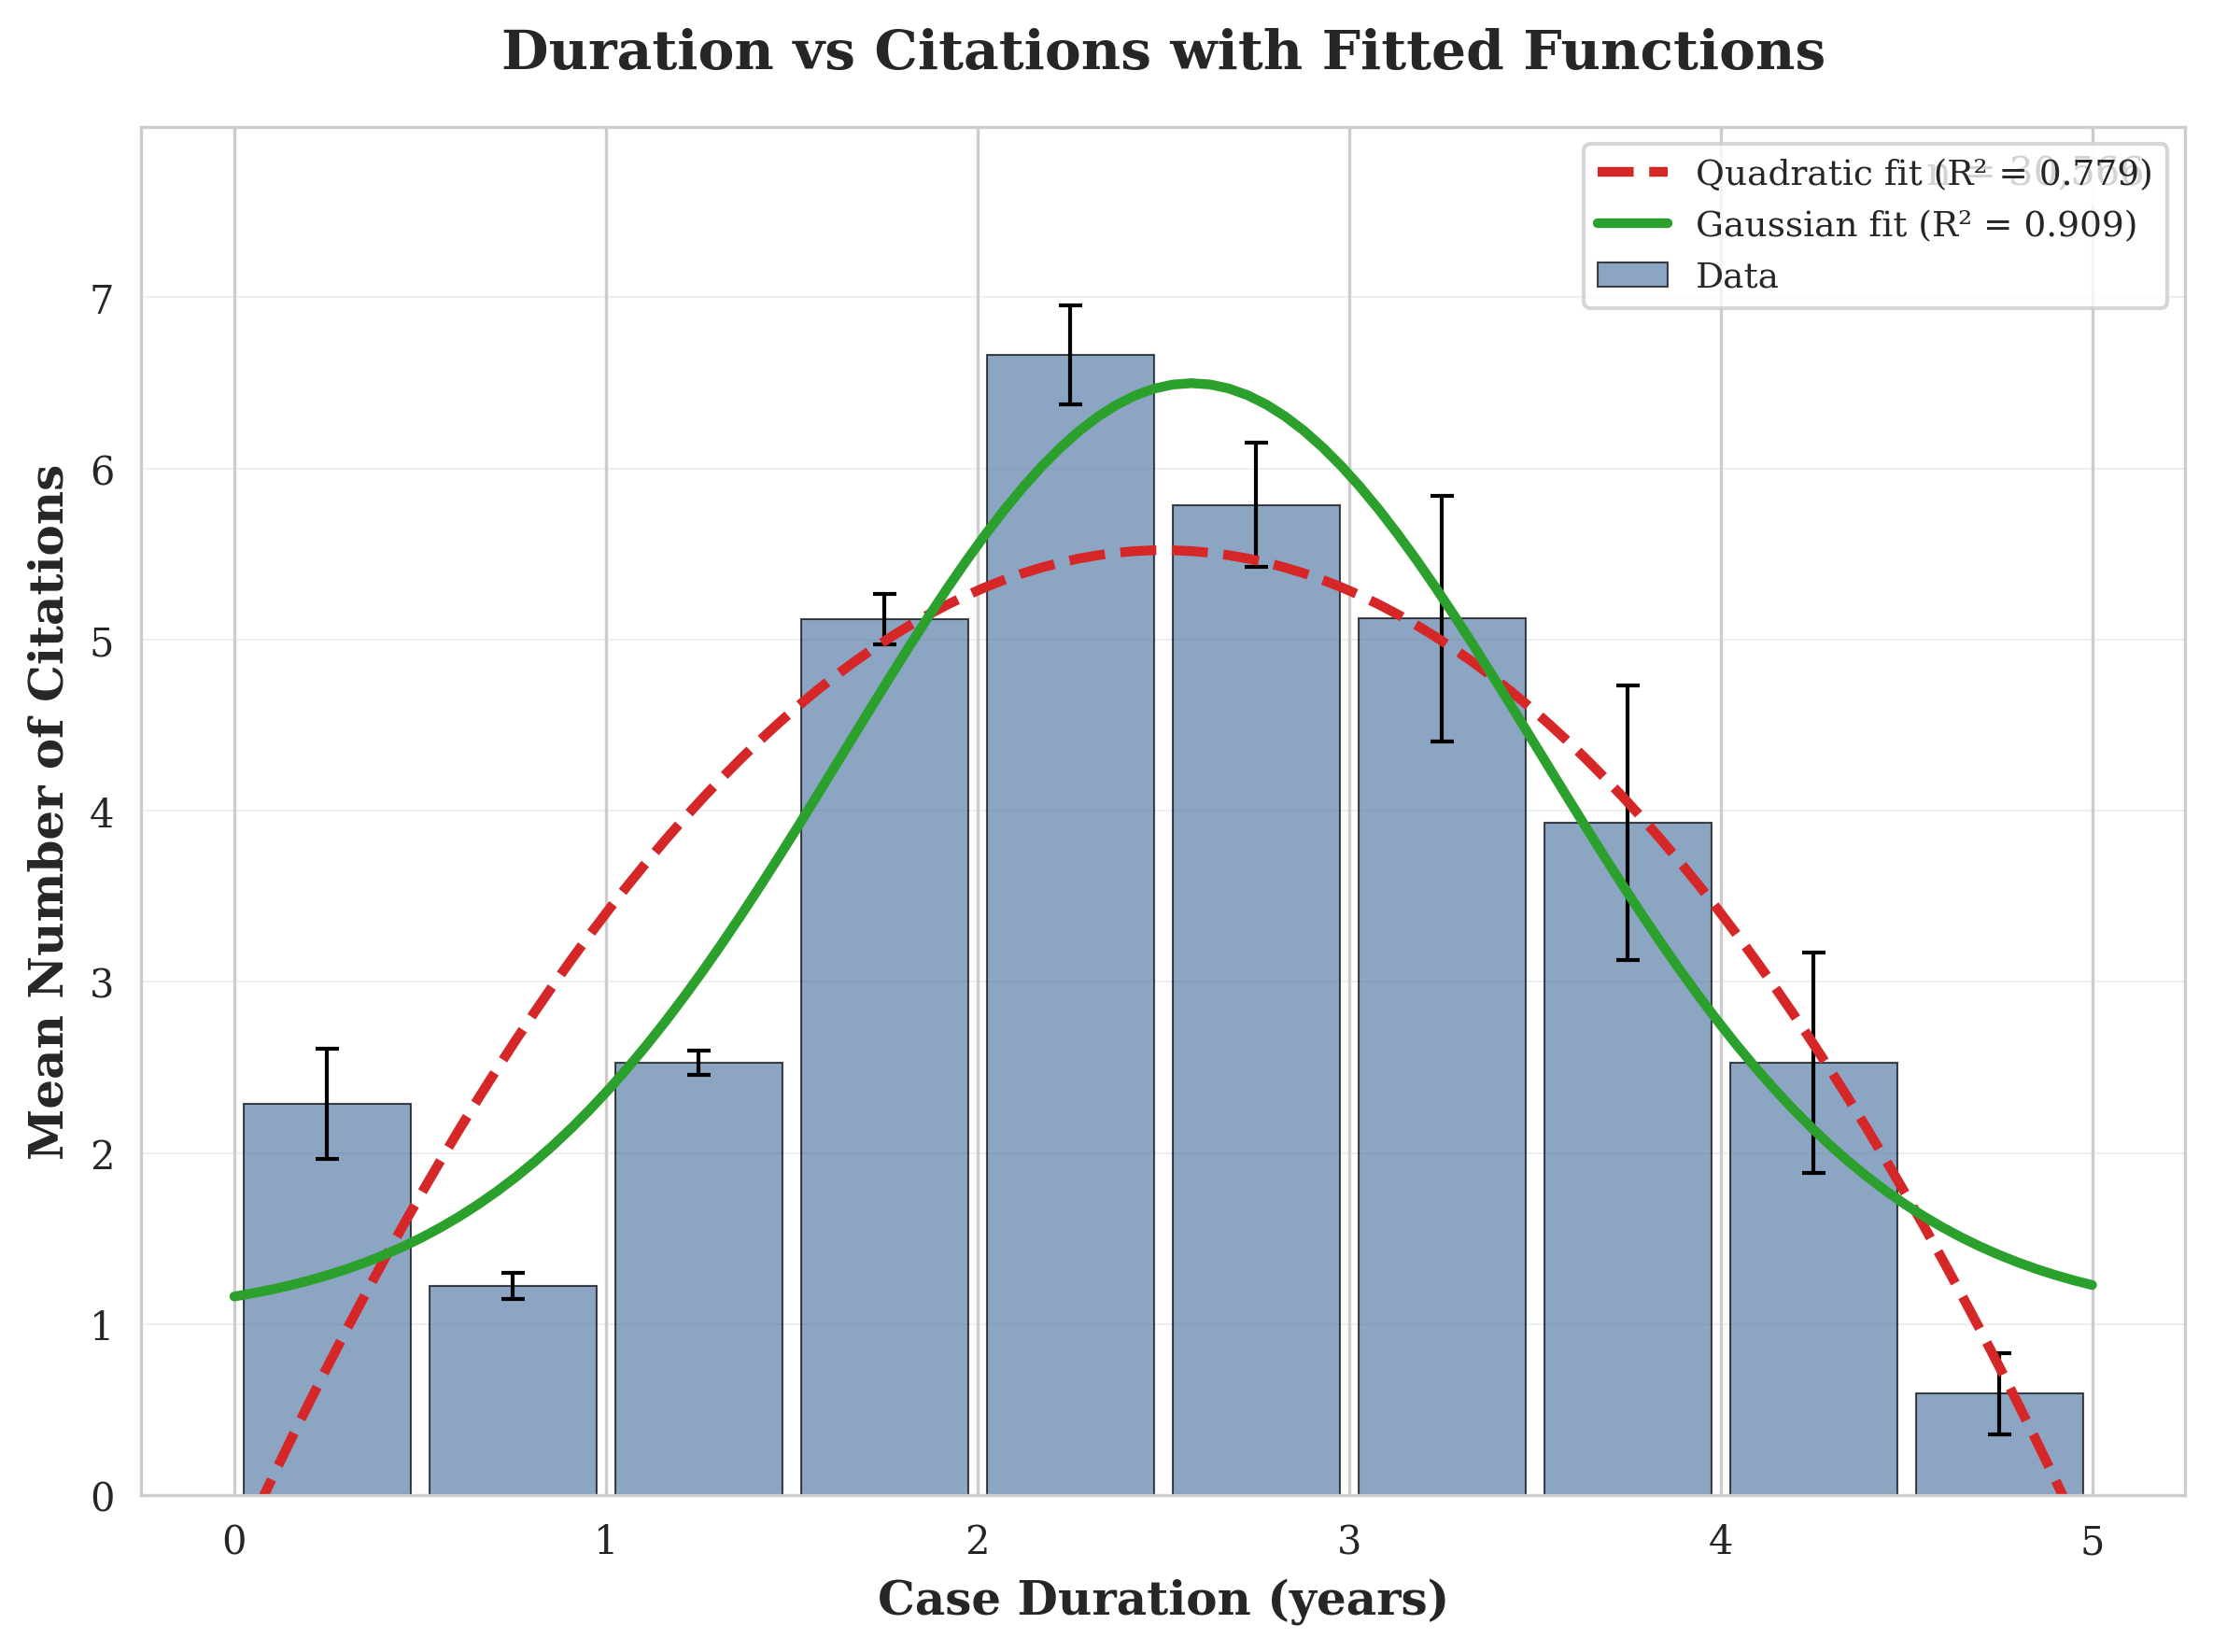


FUNCTION FIT RESULTS

--- Quadratic: f(x) = ax² + bx + c ---
  a = -0.9425
  b = 4.7134
  c = -0.3704
  R² = 0.7791
  Peak at x = 2.50 years (citations = 5.52)

--- Gaussian: f(x) = a·exp(-(x-μ)²/2σ²) + c ---
  a (amplitude) = 5.4583
  μ (mean/peak) = 2.5767 years
  σ (std dev)   = 0.9341 years
  c (baseline)  = 1.0398
  R² = 0.9092

Best fit: Gaussian (higher R²)


In [ ]:
# ============================================================================
# FIT FUNCTION TO DURATION VS CITATIONS DATA
# ============================================================================

from scipy.optimize import curve_fit

# Define candidate functions
def quadratic(x, a, b, c):
    return a * x**2 + b * x + c

def gaussian(x, a, mu, sigma, c):
    return a * np.exp(-((x - mu)**2) / (2 * sigma**2)) + c

# Fit quadratic
popt_quad, pcov_quad = curve_fit(quadratic, bin_centers, mean_citations)
y_pred_quad = quadratic(bin_centers, *popt_quad)
ss_res_quad = np.sum((mean_citations - y_pred_quad)**2)
ss_tot = np.sum((mean_citations - np.mean(mean_citations))**2)
r2_quad = 1 - (ss_res_quad / ss_tot)

# Fit Gaussian
p0_gauss = [max(mean_citations), 2.0, 1.0, 0]  # Initial guess
popt_gauss, pcov_gauss = curve_fit(gaussian, bin_centers, mean_citations, p0=p0_gauss, maxfev=5000)
y_pred_gauss = gaussian(bin_centers, *popt_gauss)
ss_res_gauss = np.sum((mean_citations - y_pred_gauss)**2)
r2_gauss = 1 - (ss_res_gauss / ss_tot)

# Create figure with fitted curves
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Bar plot
bars = ax.bar(bin_centers, mean_citations, width=0.45, 
              color='#5A7FA8', edgecolor='black', linewidth=0.5, alpha=0.7, label='Data')

# Error bars
ax.errorbar(bin_centers, mean_citations, yerr=sem_citations, 
            fmt='none', ecolor='black', capsize=3, capthick=1, linewidth=1)

# Smooth x values for curves
x_smooth = np.linspace(0, max_duration_years, 100)

# Plot fitted curves
ax.plot(x_smooth, quadratic(x_smooth, *popt_quad), 
        color='#D62728', linewidth=2.5, linestyle='--', 
        label=f'Quadratic fit (R² = {r2_quad:.3f})')

ax.plot(x_smooth, gaussian(x_smooth, *popt_gauss), 
        color='#2CA02C', linewidth=2.5, linestyle='-', 
        label=f'Gaussian fit (R² = {r2_gauss:.3f})')

# Labels and title
ax.set_xlabel('Case Duration (years)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Number of Citations', fontsize=12, fontweight='bold')
ax.set_title('Duration vs Citations with Fitted Functions', 
             fontsize=14, fontweight='bold', pad=15)

# Limits
ax.set_xlim(-0.25, max_duration_years + 0.25)
ax.set_ylim(0, max(mean_citations) * 1.2)

# Legend
ax.legend(loc='upper right', frameon=True, fancybox=True, fontsize=9)

# Grid
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, axis='y')
ax.set_axisbelow(True)
ax.set_xticks(range(0, max_duration_years + 1))

plt.tight_layout()
plt.show()

# Print fit results
print(f"\n{'='*60}")
print("FUNCTION FIT RESULTS")
print(f"{'='*60}")

print(f"\n--- Quadratic: f(x) = ax² + bx + c ---")
print(f"  a = {popt_quad[0]:.4f}")
print(f"  b = {popt_quad[1]:.4f}")
print(f"  c = {popt_quad[2]:.4f}")
print(f"  R² = {r2_quad:.4f}")
# Find peak of quadratic
peak_x_quad = -popt_quad[1] / (2 * popt_quad[0])
peak_y_quad = quadratic(peak_x_quad, *popt_quad)
print(f"  Peak at x = {peak_x_quad:.2f} years (citations = {peak_y_quad:.2f})")

print(f"\n--- Gaussian: f(x) = a·exp(-(x-μ)²/2σ²) + c ---")
print(f"  a (amplitude) = {popt_gauss[0]:.4f}")
print(f"  μ (mean/peak) = {popt_gauss[1]:.4f} years")
print(f"  σ (std dev)   = {popt_gauss[2]:.4f} years")
print(f"  c (baseline)  = {popt_gauss[3]:.4f}")
print(f"  R² = {r2_gauss:.4f}")

print(f"\n{'='*60}")
best_fit = "Gaussian" if r2_gauss > r2_quad else "Quadratic"
print(f"Best fit: {best_fit} (higher R²)")
print(f"{'='*60}")

GAUSSIAN COMPARISON

Fitted Gaussian:
  μ = 2.577, σ = 0.934
  R² = 0.9092

Fixed Gaussian (μ=2.5, σ=1.0):
  a = 5.574, c = 0.816
  R² = 0.8984


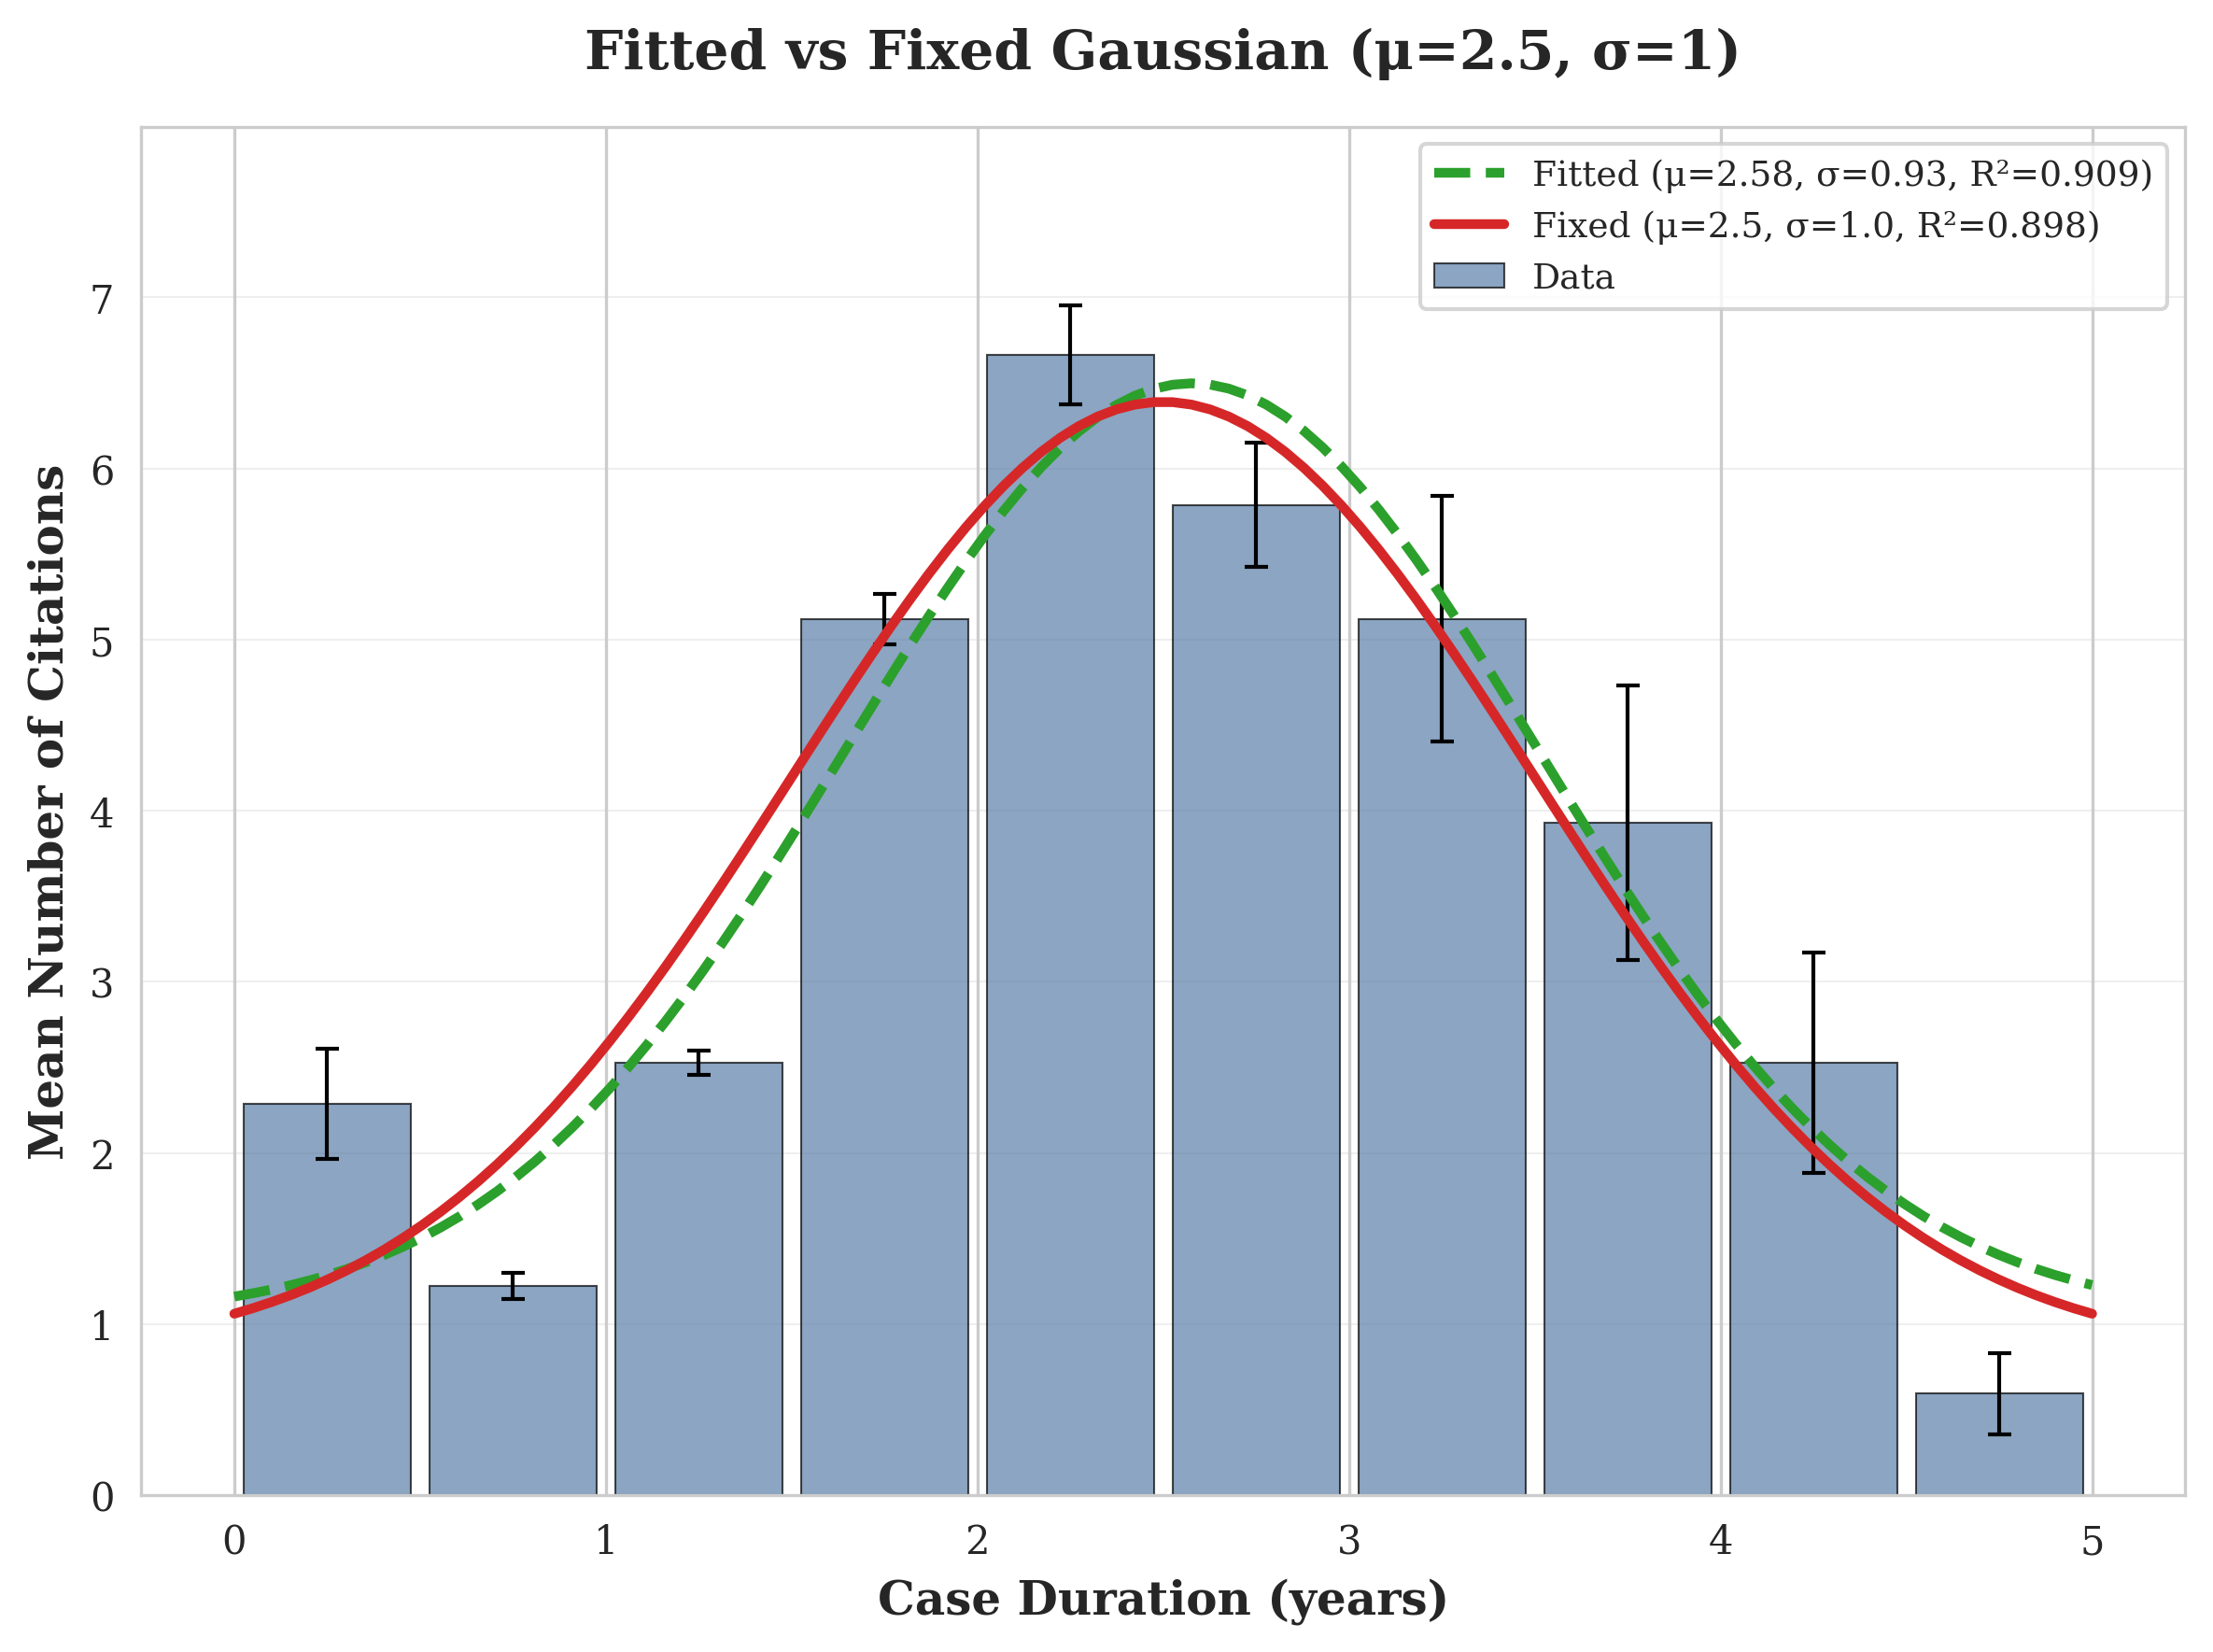

In [25]:
# ============================================================================
# COMPARE FITTED GAUSSIAN VS FIXED μ=2.5, σ=1
# ============================================================================

# Fixed Gaussian: only fit amplitude and baseline
def gaussian_fixed(x, a, c):
    mu, sigma = 2.5, 1.0
    return a * np.exp(-((x - mu)**2) / (2 * sigma**2)) + c

# Fit with fixed mu/sigma
popt_fixed, _ = curve_fit(gaussian_fixed, bin_centers, mean_citations)
y_pred_fixed = gaussian_fixed(bin_centers, *popt_fixed)
ss_res_fixed = np.sum((mean_citations - y_pred_fixed)**2)
r2_fixed = 1 - (ss_res_fixed / ss_tot)

# Compare
print(f"{'='*60}")
print("GAUSSIAN COMPARISON")
print(f"{'='*60}")
print(f"\nFitted Gaussian:")
print(f"  μ = {popt_gauss[1]:.3f}, σ = {popt_gauss[2]:.3f}")
print(f"  R² = {r2_gauss:.4f}")
print(f"\nFixed Gaussian (μ=2.5, σ=1.0):")
print(f"  a = {popt_fixed[0]:.3f}, c = {popt_fixed[1]:.3f}")
print(f"  R² = {r2_fixed:.4f}")
print(f"{'='*60}")

# Plot comparison
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Bars
bars = ax.bar(bin_centers, mean_citations, width=0.45, 
              color='#5A7FA8', edgecolor='black', linewidth=0.5, alpha=0.7, label='Data')
ax.errorbar(bin_centers, mean_citations, yerr=sem_citations, 
            fmt='none', ecolor='black', capsize=3, capthick=1, linewidth=1)

x_smooth = np.linspace(0, max_duration_years, 100)

# Fitted Gaussian
ax.plot(x_smooth, gaussian(x_smooth, *popt_gauss), 
        color='#2CA02C', linewidth=2.5, linestyle='--',
        label=f'Fitted (μ={popt_gauss[1]:.2f}, σ={popt_gauss[2]:.2f}, R²={r2_gauss:.3f})')

# Fixed Gaussian
ax.plot(x_smooth, gaussian_fixed(x_smooth, *popt_fixed), 
        color='#D62728', linewidth=2.5, linestyle='-',
        label=f'Fixed (μ=2.5, σ=1.0, R²={r2_fixed:.3f})')

ax.set_xlabel('Case Duration (years)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Number of Citations', fontsize=12, fontweight='bold')
ax.set_title('Fitted vs Fixed Gaussian (μ=2.5, σ=1)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(-0.25, max_duration_years + 0.25)
ax.set_ylim(0, max(mean_citations) * 1.2)
ax.legend(loc='upper right', frameon=True, fancybox=True, fontsize=9)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, axis='y')
ax.set_axisbelow(True)
ax.set_xticks(range(0, max_duration_years + 1))

plt.tight_layout()
plt.show()

Using 109,783 data points (excluded 396 zeros)
DISTRIBUTION FIT COMPARISON FOR CITATION LAG
Distribution    KS Statistic   AIC             Log-Lik     
----------------------------------------------------------------------
Exponential     0.0243         643544.7        -321770.4   
Log-normal      0.0464         649808.9        -324901.5   
✓ Best fit by AIC: Exponential


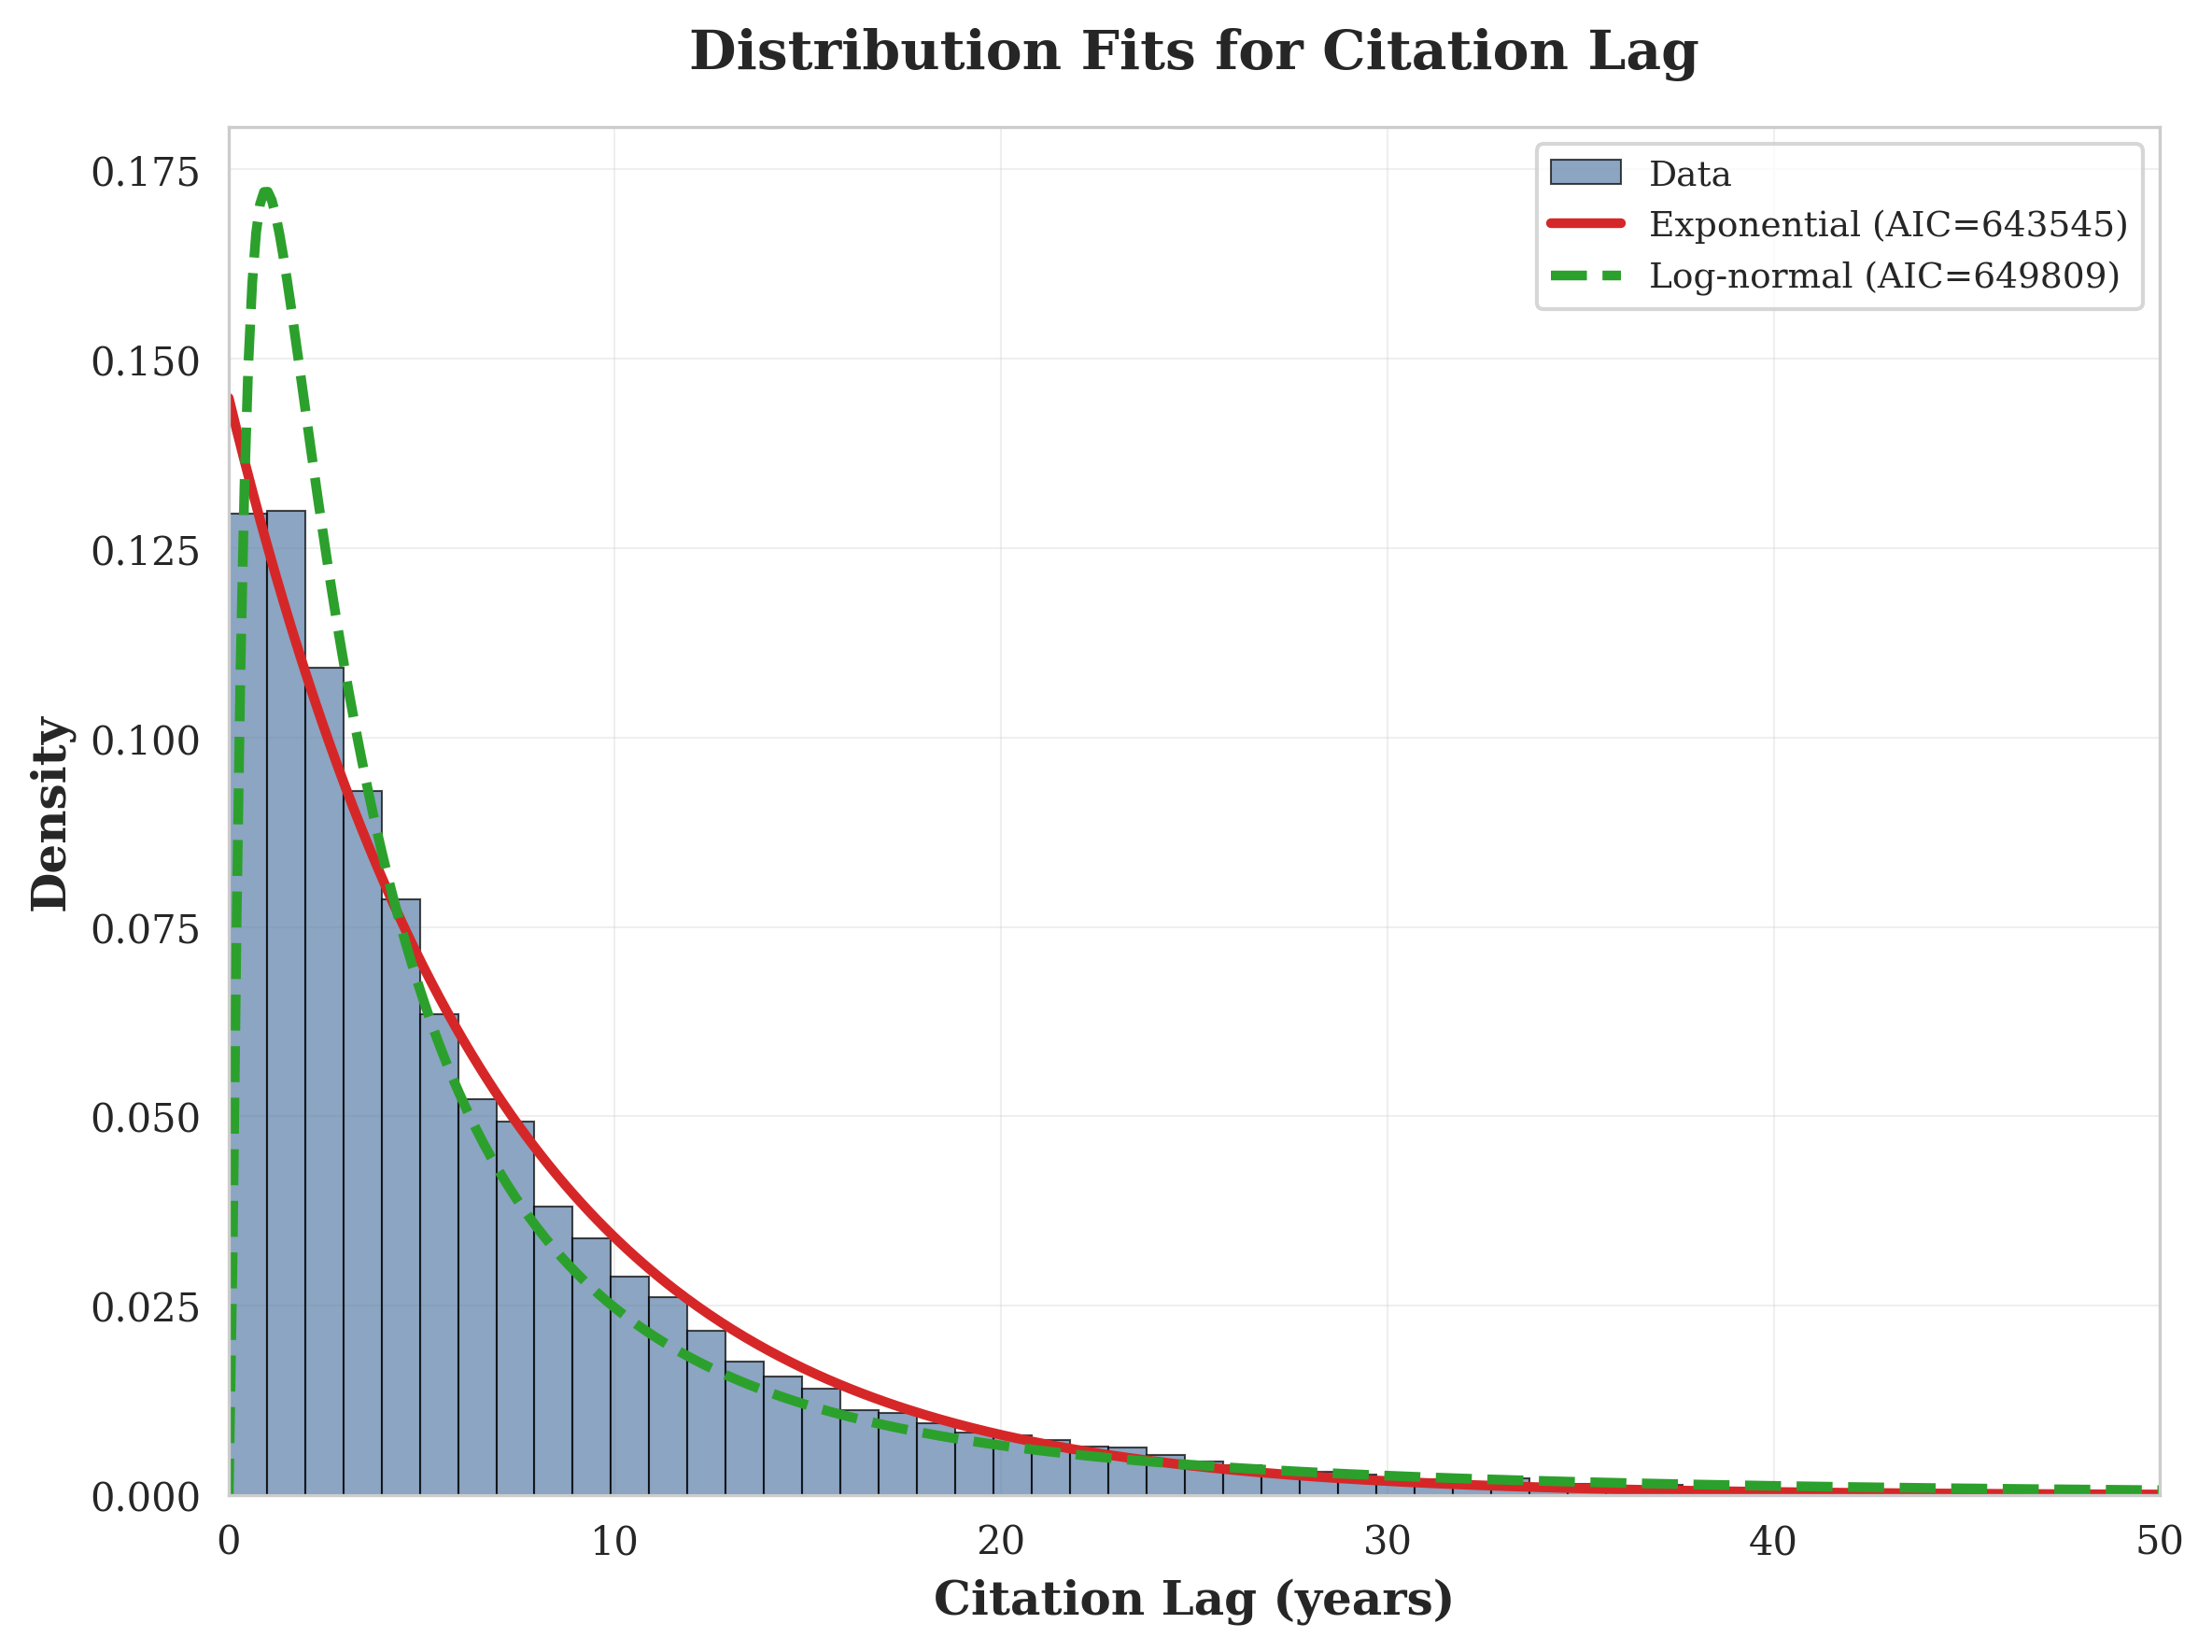


BEST FIT: Exponential
  λ (rate) = 0.1450
  Mean = 6.90 years


In [30]:
# ============================================================================
# FIT DISTRIBUTIONS TO CITATION LAG DATA
# ============================================================================

from scipy import stats as sp_stats
from scipy.stats import expon, lognorm, gamma, weibull_min

# Use lags_years from earlier cell - filter out zeros for log-normal
data = lags_years.values
data = data[data > 0]  # Log-normal requires strictly positive values
print(f"Using {len(data):,} data points (excluded {len(lags_years) - len(data)} zeros)")

# Fit distributions
fits = {}

# Exponential
params = expon.fit(data, floc=0)
fits['Exponential'] = {'params': params, 'dist': expon}

# Log-normal
params = lognorm.fit(data, floc=0)
fits['Log-normal'] = {'params': params, 'dist': lognorm}


# Calculate goodness-of-fit (KS test and log-likelihood)
for name, fit_data in fits.items():
    dist = fit_data['dist']
    params = fit_data['params']
    
    # KS test
    ks_stat, ks_p = sp_stats.kstest(data, dist.cdf, args=params)
    fit_data['ks_stat'] = ks_stat
    fit_data['ks_p'] = ks_p
    
    # Log-likelihood
    log_lik = np.sum(dist.logpdf(data, *params))
    fit_data['log_lik'] = log_lik
    
    # AIC (Akaike Information Criterion) - lower is better
    k = len(params)
    aic = 2 * k - 2 * log_lik
    fit_data['aic'] = aic

# Sort by AIC
sorted_fits = sorted(fits.items(), key=lambda x: x[1]['aic'])

# Print comparison
print(f"{'='*70}")
print("DISTRIBUTION FIT COMPARISON FOR CITATION LAG")
print(f"{'='*70}")
print(f"{'Distribution':<15} {'KS Statistic':<14} {'AIC':<15} {'Log-Lik':<12}")
print(f"{'-'*70}")
for name, data_fit in sorted_fits:
    print(f"{name:<15} {data_fit['ks_stat']:<14.4f} {data_fit['aic']:<15.1f} {data_fit['log_lik']:<12.1f}")
print(f"{'='*70}")
print(f"✓ Best fit by AIC: {sorted_fits[0][0]}")

# Plot
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Histogram
bins = int(data.max() - data.min()) + 1
n, bin_edges, patches = ax.hist(data, bins=bins, density=True, 
                                 color='#5A7FA8', alpha=0.7, 
                                 edgecolor='black', linewidth=0.5, label='Data')

# X values for fitted curves
x = np.linspace(0.01, data.max(), 500)

# Plot fitted distributions
colors = ['#D62728', '#2CA02C', '#9467BD', '#FF7F0E']
linestyles = ['-', '--', ':', '-.']

for i, (name, fit_data) in enumerate(sorted_fits):
    dist = fit_data['dist']
    params = fit_data['params']
    y = dist.pdf(x, *params)
    ax.plot(x, y, color=colors[i], linewidth=2.5, linestyle=linestyles[i],
            label=f'{name} (AIC={fit_data["aic"]:.0f})')

ax.set_xlabel('Citation Lag (years)', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('Distribution Fits for Citation Lag', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 50)
ax.legend(loc='upper right', frameon=True, fancybox=True, fontsize=9)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Print best fit parameters
best_name, best_fit = sorted_fits[0]
print(f"\n{'='*50}")
print(f"BEST FIT: {best_name}")
print(f"{'='*50}")
if best_name == 'Log-normal':
    s, loc, scale = best_fit['params']
    mu = np.log(scale)
    sigma = s
    print(f"  σ (shape) = {s:.4f}")
    print(f"  μ (log-scale) = {mu:.4f}")
    print(f"  Median = {np.exp(mu):.2f} years")
    print(f"  Mean = {np.exp(mu + sigma**2/2):.2f} years")

elif best_name == 'Exponential':
    loc, scale = best_fit['params']
    print(f"  λ (rate) = {1/scale:.4f}")
    print(f"  Mean = {scale:.2f} years")
print(f"{'='*50}")